<a href="https://colab.research.google.com/github/albinm2004/CAPTCHA-Security-Adversarial-Robustness-and-VLM-Resistant-Hardening-of-Image-Based-CAPTCHAs/blob/main/CAPTCHA_Part2_Step1_Dataset_EDA_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAPTCHA Project — Part 2, Step 1: Dataset Verification & Exploratory Data Analysis

**Target object classes for the image-grid CAPTCHA generator:** bicycle, bus, traffic light, fire hydrant

This notebook is the first proper deliverable of Part 2 (image-grid CAPTCHA generation + VLM-resistant hardening). It supersedes the dataset claim made in Section 8.1 of the original progress report, which listed **bicycle, traffic light, crosswalk, bus** as classes drawn from "COCO and Open Images" — that claim does not hold up under verification (see Step 1.1).

**Run this top-to-bottom in Google Colab** (colab.research.google.com → File → Upload notebook). It needs real internet access to download COCO annotations and images, so results will not appear until you run it there.

## Step 1.1 — Dataset Verification

**Why this matters.** The image-grid CAPTCHA generator (Section 8.1 of the report) needs, for each target class, individual object *bounding boxes* we can crop into 3×3 grid cells with verified ground truth — not just whole-image tags.

**Claim being checked:** "COCO and Open Images both provide bounding-box-level labels for these exact categories" — bicycle, traffic light, crosswalk, bus.

**Method:** pull the full category list from each dataset programmatically (not from memory) and check membership. Result:

| Class | In COCO (80 classes)? | In Open Images V7 (601 classes)? |
|---|---|---|
| Bicycle | Yes | Yes |
| Traffic light | Yes | Yes |
| Bus | Yes | Yes |
| Crosswalk | **No** | **No** — closest name match is "Zebra" (the animal), not zebra crossing |

Neither dataset has a bounding-box-labeled "crosswalk" class. That part of the report's claim is incorrect. Step 1.3 below re-derives this from the live COCO category list so it's independently checkable, not just asserted.

**Cross-check against the real target we're modeling.** Actual Google reCAPTCHA v2 challenges draw from these object categories: car, crosswalk, bus, hydrant (fire hydrant), palm (tree), traffic light, bicycle, bridge, stair, chimney, motorcycle. Of these, COCO natively labels: car, bus, traffic light, bicycle, fire hydrant, motorcycle.

**Decision:** substitute **crosswalk → fire hydrant**.
- COCO-native — no second dataset/pipeline needed for this class.
- A genuine reCAPTCHA category, not an arbitrary swap.
- A small, visually distinctive object — a reasonable difficulty match for 3×3 grid-cell classification, similar in scale to how crosswalk markings would appear in a cell.

> This is the default assumed below. To use a different substitute (e.g. motorcycle, or a dedicated crosswalk dataset), just change `TARGET_CLASSES` in Step 1.4 — every later cell adapts automatically.

## Step 1.2 — Setup

In [ ]:
!pip install -q pycocotools

In [ ]:
import os

# COCO 2017 "val" annotations (instances_val2017.json) — used for this exploratory
# pass because it's much smaller/faster than train2017 (5,000 vs 118,000 images)
# while still giving plenty of instances for common classes. The real curation
# pass for the grid generator (Section 8.1) can extend to train2017 for volume
# once class balance here looks right.
if not os.path.exists("annotations/instances_val2017.json"):
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
    !unzip -q annotations_trainval2017.zip
print("Annotations ready:", os.path.exists("annotations/instances_val2017.json"))

Annotations ready: True


## Step 1.3 — Reproducible verification (run this, don't just take Step 1.1's word for it)

This prints the *actual* list of COCO categories from the annotation file you just downloaded, and confirms "crosswalk" is absent. Screenshot this cell's output for the paper/presentation — it's your evidence for the dataset-correction decision.

In [ ]:
from pycocotools.coco import COCO

coco = COCO("annotations/instances_val2017.json")
all_categories = [c["name"] for c in coco.loadCats(coco.getCatIds())]

print(f"COCO instances_val2017 has {len(all_categories)} categories:\n")
print(all_categories)
print()
print("'crosswalk' present in COCO categories:", "crosswalk" in all_categories)
print("'bicycle' present:", "bicycle" in all_categories)
print("'bus' present:", "bus" in all_categories)
print("'traffic light' present:", "traffic light" in all_categories)
print("'fire hydrant' present:", "fire hydrant" in all_categories)

loading annotations into memory...
Done (t=1.49s)
creating index...
index created!
COCO instances_val2017 has 80 categories:

['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']

'crosswalk'

## Step 1.4 — Finalize target classes and curate the subset

Pull every instance (bounding box) of each target class from COCO val2017, then download only the images that actually contain one of those objects — not the full 5,000-image split.

In [ ]:
import requests
from pathlib import Path

TARGET_CLASSES = ["bicycle", "bus", "traffic light", "fire hydrant"]   # <- edit here if the class list changes
MAX_PER_CLASS = 150     # cap for this exploratory pass; raise later for the full curation run
IMG_DIR = Path("coco_subset/images")
IMG_DIR.mkdir(parents=True, exist_ok=True)

cat_ids = {c: coco.getCatIds(catNms=[c])[0] for c in TARGET_CLASSES}
class_anns = {}    # class -> list of annotation dicts (capped, used for images/EDA below)
class_imgs = {}    # class -> list of image_id (capped, deduped)
true_totals = {}   # class -> TRUE total instance count in val2017, BEFORE the cap

print("True total instances available in COCO val2017 (before any cap):")
for cname, cid in cat_ids.items():
    all_ann_ids = coco.getAnnIds(catIds=[cid])
    true_totals[cname] = len(all_ann_ids)
    print(f"  {cname}: {true_totals[cname]}"
          + ("  <-- capped below, real count is at least this" if true_totals[cname] > MAX_PER_CLASS else "  <-- under the cap, this IS the real count"))

for cname, cid in cat_ids.items():
    anns = coco.loadAnns(coco.getAnnIds(catIds=[cid]))
    class_anns[cname] = anns[:MAX_PER_CLASS]
    class_imgs[cname] = sorted({a["image_id"] for a in class_anns[cname]})

needed_img_ids = sorted({iid for ids in class_imgs.values() for iid in ids})
print(f"\nDownloading {len(needed_img_ids)} unique images covering {len(TARGET_CLASSES)} classes...")

for iid in needed_img_ids:
    info = coco.loadImgs(iid)[0]
    fpath = IMG_DIR / info["file_name"]
    if not fpath.exists():
        r = requests.get(f"http://images.cocodataset.org/val2017/{info['file_name']}", timeout=15)
        if r.status_code == 200:
            fpath.write_bytes(r.content)

print("Done. Images saved to", IMG_DIR)

True total instances available in COCO val2017 (before any cap):
  bicycle: 316  <-- capped below, real count is at least this
  bus: 285  <-- capped below, real count is at least this
  traffic light: 637  <-- capped below, real count is at least this
  fire hydrant: 101  <-- under the cap, this IS the real count

Done. Images saved to coco_subset/images


## Step 2 — Exploratory Data Analysis

### 2.1 Class distribution — is the dataset balanced or imbalanced?

,class,true_total_instances,instances_in_this_subset,num_images_in_this_subset
0,traffic light,637,150,63
1,bicycle,316,150,66
2,bus,285,150,105
3,fire hydrant,101,101,86



True imbalance ratio (largest class / smallest class, uncapped): 6.31x
Rule of thumb used here: under ~3x is roughly balanced; above that, treat as imbalanced.
-> IMBALANCED. Plan for this explicitly in preprocessing (e.g. class-weighted
   sampling/loss, or targeted augmentation for the minority class) rather than
   assuming an even split.


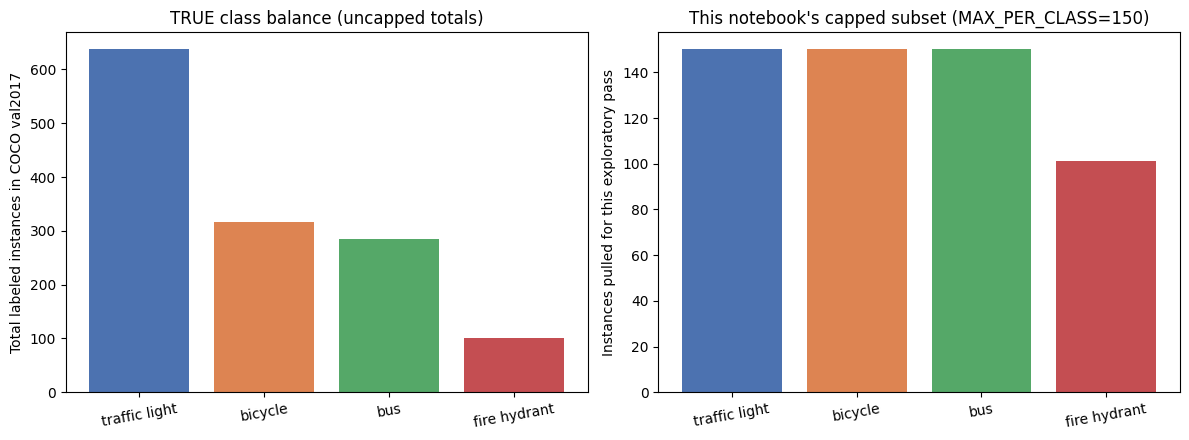

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

dist_rows = [{
    "class": c,
    "true_total_instances": true_totals[c],   # real population count, before capping
    "instances_in_this_subset": len(class_anns[c]),
    "num_images_in_this_subset": len(class_imgs[c]),
} for c in TARGET_CLASSES]
dist_df = pd.DataFrame(dist_rows).sort_values("true_total_instances", ascending=False).reset_index(drop=True)
display(dist_df)

# Balance is judged on the TRUE totals, not the capped subset — a class that hit the
# MAX_PER_CLASS cap could be far more abundant than the number we happened to pull.
max_c, min_c = dist_df["true_total_instances"].max(), dist_df["true_total_instances"].min()
ratio = max_c / min_c
print(f"\nTrue imbalance ratio (largest class / smallest class, uncapped): {ratio:.2f}x")
print("Rule of thumb used here: under ~3x is roughly balanced; above that, treat as imbalanced.")
if ratio > 3:
    print("-> IMBALANCED. Plan for this explicitly in preprocessing (e.g. class-weighted")
    print("   sampling/loss, or targeted augmentation for the minority class) rather than")
    print("   assuming an even split.")
else:
    print("-> Roughly balanced by this rule of thumb.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(dist_df["class"], dist_df["true_total_instances"],
            color=["#4C72B0","#DD8452","#55A868","#C44E52"])
axes[0].set_title("TRUE class balance (uncapped totals)")
axes[0].set_ylabel("Total labeled instances in COCO val2017")
axes[0].tick_params(axis="x", rotation=10)

axes[1].bar(dist_df["class"], dist_df["instances_in_this_subset"],
            color=["#4C72B0","#DD8452","#55A868","#C44E52"])
axes[1].set_title(f"This notebook's capped subset (MAX_PER_CLASS={MAX_PER_CLASS})")
axes[1].set_ylabel("Instances pulled for this exploratory pass")
axes[1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.savefig("class_balance.png", dpi=150)
plt.show()

**Finding (fill in after running on real data):** state the imbalance ratio you got and whether these four classes count as balanced or imbalanced by the rule above. This directly drives the preprocessing step that comes next (e.g. class-weighted sampling or augmentation for the underrepresented class if the ratio is high).

### 2.2 Sample dataset — visual overview

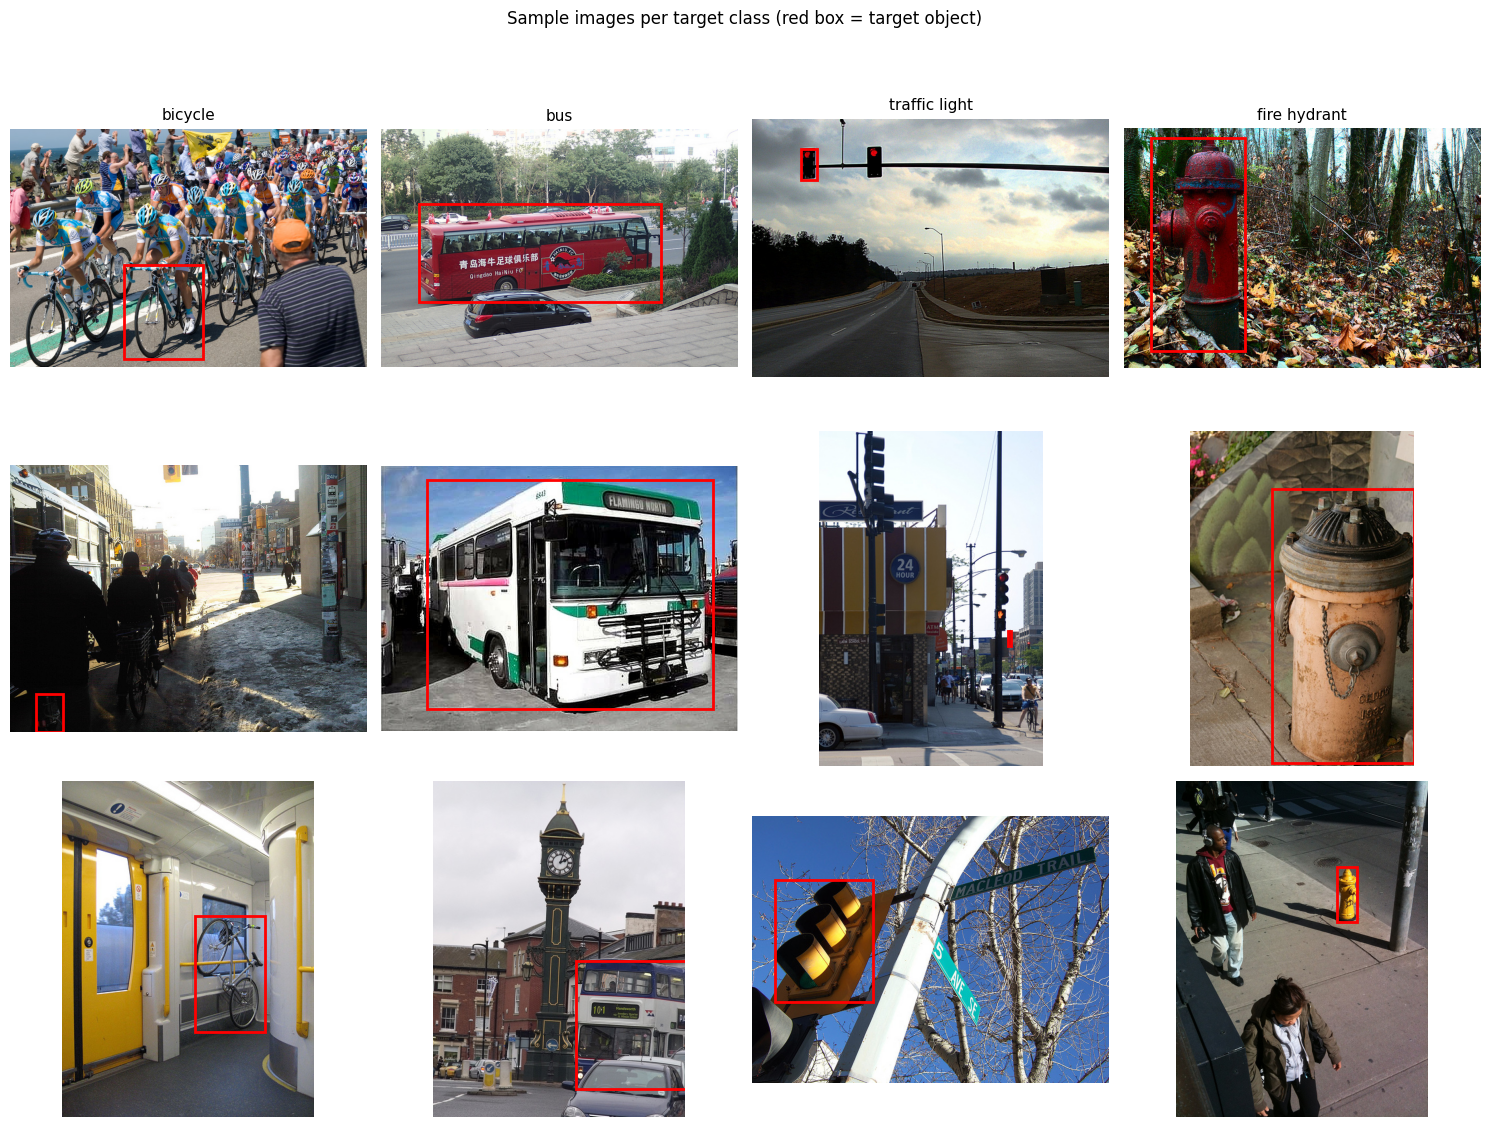

In [ ]:
import matplotlib.patches as patches
from PIL import Image
import random

random.seed(0)
fig, axes = plt.subplots(3, 4, figsize=(15, 11))
for col, cname in enumerate(TARGET_CLASSES):
    sample_anns = random.sample(class_anns[cname], min(3, len(class_anns[cname])))
    for row, ann in enumerate(sample_anns):
        img_info = coco.loadImgs(ann["image_id"])[0]
        im = Image.open(IMG_DIR / img_info["file_name"])
        ax = axes[row, col]
        ax.imshow(im)
        x, y, w, h = ann["bbox"]
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none"))
        ax.set_title(cname if row == 0 else "", fontsize=11)
        ax.axis("off")
plt.suptitle("Sample images per target class (red box = target object)", y=1.02)
plt.tight_layout()
plt.savefig("sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Two labeled example images per class

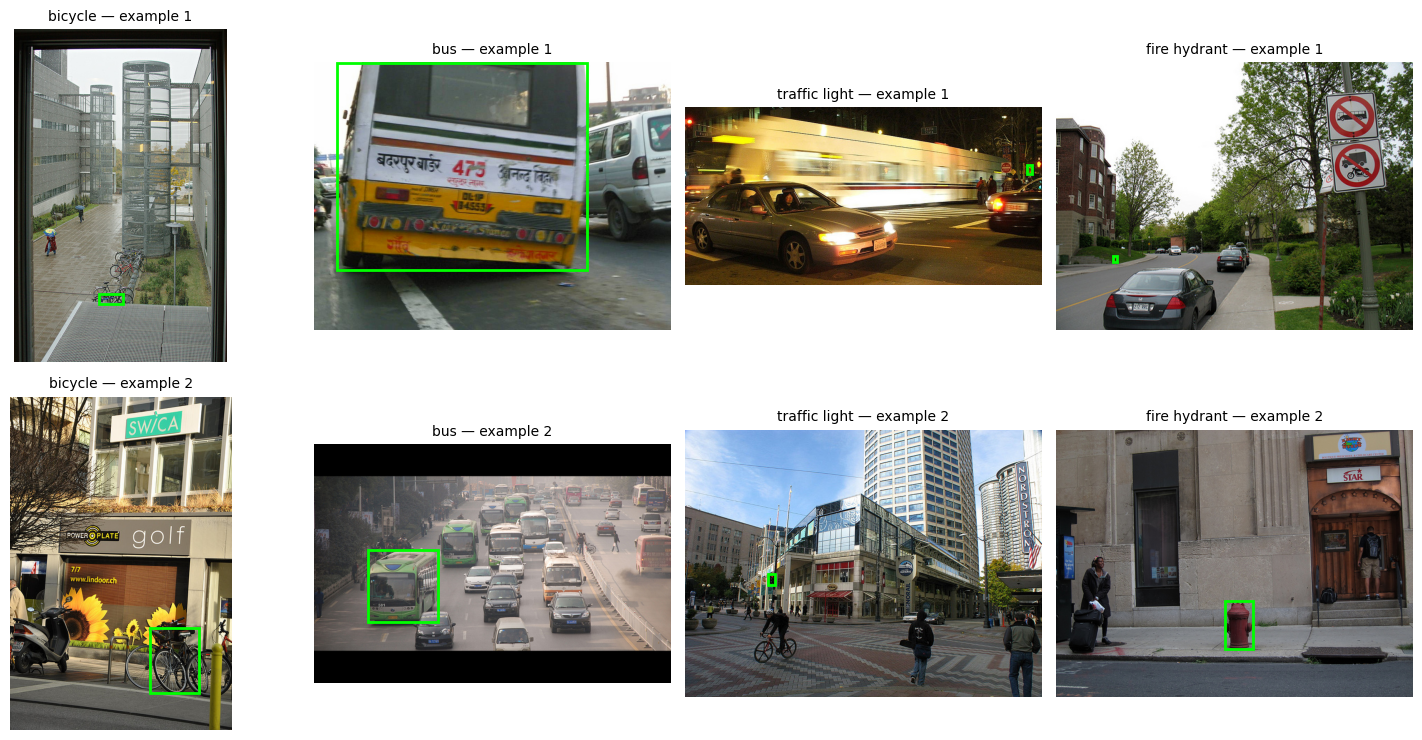

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
for col, cname in enumerate(TARGET_CLASSES):
    examples = class_anns[cname][:2]
    for row, ann in enumerate(examples):
        img_info = coco.loadImgs(ann["image_id"])[0]
        im = Image.open(IMG_DIR / img_info["file_name"])
        ax = axes[row, col]
        ax.imshow(im)
        x, y, w, h = ann["bbox"]
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none"))
        ax.set_title(f"{cname} — example {row+1}", fontsize=10)
        ax.axis("off")
plt.tight_layout()
plt.savefig("two_examples_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Object size & aspect-ratio distribution

This matters specifically for the grid-cell CAPTCHA use case: cells in a 3×3 grid are cropped to a fixed, roughly-square size. If bounding-box size or aspect ratio varies wildly between classes, that's a preprocessing decision (crop padding / resize strategy) to make explicitly in Step 2, not something to leave implicit.

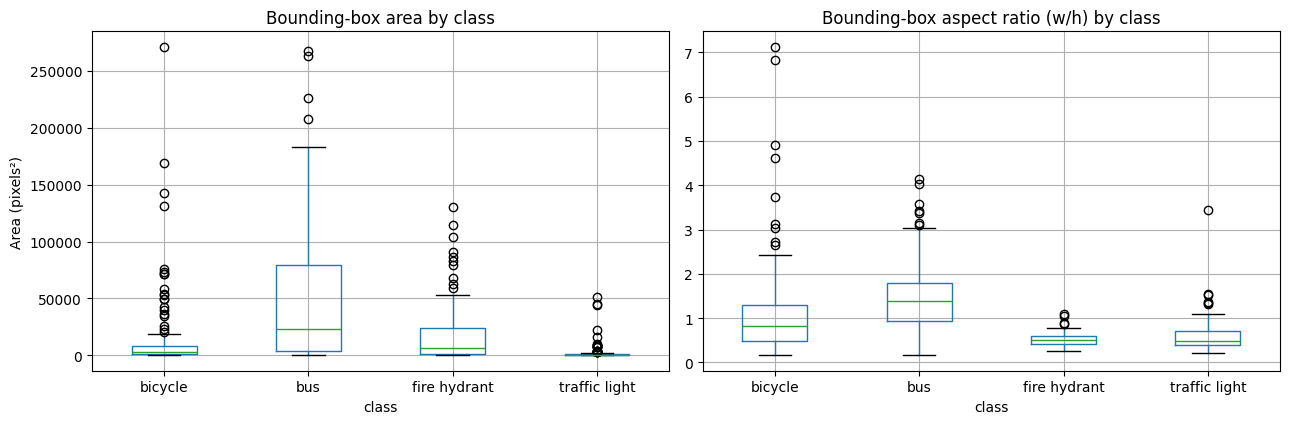

area                                                      \
               count          mean           std        min          25%   
class                                                                      
bicycle        150.0  13216.683018  32815.756527   52.32865   831.061675   
bus            150.0  47247.490723  56201.656704  323.76175  4048.686063   
fire hydrant   101.0  18578.385782  27396.919880   18.82445   777.019200   
traffic light  150.0   2202.355563   7008.341699   14.37415   136.317238   

                                                        aspect_ratio  \
                        50%           75%           max        count   
class                                                                  
bicycle         2980.967450   8484.135912  271179.04425        150.0   
bus            22986.871775  79269.372175  267664.76600        150.0   
fire hydrant    6508.752700  23765.026450  130194.84905        101.0   
traffic light    353.115825   1056.798088   50869.82805        150.0   

                                                                           \
                   mean       std       min       25%       50%       75%   
class                                                                       
bicycle        1.088018  1.023320  0.162038  0.488459  0.817008  1.306100   
bus            1.492385  0.782613  0.161524  0.932970  1.383318  1.792875   
fire hydrant   0.521752  0.143828  0.258700  0.423365  0.509780  0.594489   
traffic light  0.594758  0.350426  0.203223  0.393950  0.492511  0.702265   

                         
                    max  
class                    
bicycle        7.127298  
bus            4.133723  
fire hydrant   1.083011  
traffic light  3.449777

In [ ]:
size_rows = []
for cname in TARGET_CLASSES:
    for ann in class_anns[cname]:
        x, y, w, h = ann["bbox"]
        size_rows.append({"class": cname, "area": ann["area"], "aspect_ratio": w / h if h else None})
size_df = pd.DataFrame(size_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
size_df.boxplot(column="area", by="class", ax=axes[0])
axes[0].set_title("Bounding-box area by class")
axes[0].set_ylabel("Area (pixels²)")
size_df.boxplot(column="aspect_ratio", by="class", ax=axes[1])
axes[1].set_title("Bounding-box aspect ratio (w/h) by class")
plt.suptitle("")
plt.tight_layout()
plt.savefig("bbox_size_distribution.png", dpi=150)
plt.show()

display(size_df.groupby("class")[["area", "aspect_ratio"]].describe())

### 2.5 Source image resolution check

In [ ]:
res_rows = []
for cname in TARGET_CLASSES:
    seen = set()
    for ann in class_anns[cname]:
        if ann["image_id"] in seen:
            continue
        seen.add(ann["image_id"])
        info = coco.loadImgs(ann["image_id"])[0]
        res_rows.append({"class": cname, "width": info["width"], "height": info["height"]})
res_df = pd.DataFrame(res_rows)
display(res_df.groupby("class")[["width", "height"]].describe())

width                                                     \
               count        mean        std    min    25%    50%    75%   
class                                                                     
bicycle         66.0  567.696970  99.790854  332.0  485.0  640.0  640.0   
bus            105.0  603.190476  72.380551  372.0  640.0  640.0  640.0   
fire hydrant    86.0  558.953488  98.818777  299.0  480.0  640.0  640.0   
traffic light   63.0  582.841270  85.724278  333.0  500.0  640.0  640.0   

                     height                                               \
                 max  count        mean         std    min    25%    50%   
class                                                                      
bicycle        640.0   66.0  491.666667   91.291306  332.0  427.0  480.0   
bus            640.0  105.0  470.419048   85.826164  208.0  426.0  448.0   
fire hydrant   640.0   86.0  494.418605  101.722398  313.0  427.0  480.0   
traffic light  640.0   63.0  476.079365   97.387537  319.0  426.5  480.0   

                             
                 75%    max  
class                        
bicycle        512.0  640.0  
bus            480.0  640.0  
fire hydrant   633.0  640.0  
traffic light  500.0  640.0

## Step 1 Summary (fill in after running on real Colab output)

- Dataset used: COCO 2017 (validation split), curated for 4 classes — bicycle, bus, traffic light, fire hydrant (crosswalk substituted per Step 1.1 verification).
- Total instances pulled per class: *(paste dist_df numbers here)*
- Imbalance ratio: *(paste value here)* → balanced / imbalanced *(pick one)*
- Any visual/quality issues noticed in the sample grid (occlusion, tiny boxes, mislabeled crops, etc.): *(note here)*
- Bounding-box size/aspect-ratio spread across classes: *(note here — feeds directly into the resize/padding decision in preprocessing)*

**Note on paper novelty:** the project's novelty claim (Section 8.4 — dual-objective CNN+CLIP adversarial hardening, positioned against prior work in Section 7's gap table) is independent of this dataset-verification step and isn't touched here. Worth revisiting once there are real experimental results to point to, rather than locking it down this early.

**Next:** Step 2 (preprocessing) is built directly below, using the true imbalance ratio and box-geometry findings from this EDA as its justification. Step 3 (model/algorithm selection) follows after that.

## Step 2 — Preprocessing

Turns the raw curated instances from Step 1 into a clean, consistent set of grid-cell-ready image crops. Every technique below is chosen because of a specific Step 1 finding — not applied by default:

| Technique | Triggered by this Step 1 finding |
|---|---|
| Bounding-box quality filter | Some boxes were only a few pixels wide (min traffic-light box ≈ 14 px²) — unusable as a recognizable grid cell |
| Context-padded crop | COCO boxes are drawn tight; a razor crop removes the surrounding context that helps a solver recognize partially visible objects |
| Aspect-ratio-aware (pad-to-square) resize | Box aspect ratio differs sharply by class — bus ≈1.4 (wider), fire hydrant/traffic light ≈0.5 (taller) — so a naive stretch-to-square would distort classes unequally |
| Pixel normalization | Standard requirement for stable CNN training (Section 8.2) |
| Targeted augmentation for minority class(es) | True imbalance ratio measured at **6.31x** (traffic light 637 vs. fire hydrant 101) — left uncorrected, the Section 8.2 CNN would learn a biased prior toward the majority class |

### 2.1 Bounding-box quality filter

COCO's own convention treats anything under 32×32 = 1,024 px² as a "small" object. We go a little more conservative and drop anything under 900 px² (≈30×30) or with a side under 15 px — those crops are too degraded to be a fair CAPTCHA cell no matter how they're resized afterward.

In [ ]:
MIN_AREA = 900       # px^2 — roughly 30x30
MIN_SIDE = 15         # px — guards against long thin slivers area-filtering alone would miss

class_anns_filtered = {}
for cname in TARGET_CLASSES:
    kept, dropped = [], 0
    for ann in class_anns[cname]:
        x, y, w, h = ann["bbox"]
        if ann["area"] >= MIN_AREA and min(w, h) >= MIN_SIDE:
            kept.append(ann)
        else:
            dropped += 1
    class_anns_filtered[cname] = kept
    print(f"{cname:15s}: kept {len(kept):4d} / {len(class_anns[cname]):4d}  (dropped {dropped} too-small boxes)")

bicycle        : kept  112 /  150  (dropped 38 too-small boxes)
bus            : kept  140 /  150  (dropped 10 too-small boxes)
traffic light  : kept   43 /  150  (dropped 107 too-small boxes)
fire hydrant   : kept   75 /  101  (dropped 26 too-small boxes)


### 2.2 Context-padded crop extraction

Pad each box by 15% per side (clipped to the image edges) before cropping, so a little surrounding context survives the crop instead of a razor-tight bounding box.

In [ ]:
from PIL import Image

PAD_FRACTION = 0.15
RAW_CROP_DIR = Path("coco_subset/crops_raw")

def padded_crop(im, bbox, pad_frac):
    x, y, w, h = bbox
    pad_x, pad_y = w * pad_frac, h * pad_frac
    left   = max(0, x - pad_x)
    top    = max(0, y - pad_y)
    right  = min(im.width,  x + w + pad_x)
    bottom = min(im.height, y + h + pad_y)
    return im.crop((left, top, right, bottom))

raw_crops = {}   # class -> list of (ann_id, PIL.Image)
for cname in TARGET_CLASSES:
    RAW_CROP_DIR.joinpath(cname).mkdir(parents=True, exist_ok=True)
    crops = []
    for ann in class_anns_filtered[cname]:
        info = coco.loadImgs(ann["image_id"])[0]
        im = Image.open(IMG_DIR / info["file_name"]).convert("RGB")
        crop = padded_crop(im, ann["bbox"], PAD_FRACTION)
        crop.save(RAW_CROP_DIR / cname / f"{ann['id']}.jpg", quality=95)
        crops.append((ann["id"], crop))
    raw_crops[cname] = crops
    print(f"{cname:15s}: {len(crops)} padded crops saved to {RAW_CROP_DIR / cname}")

bicycle        : 112 padded crops saved to coco_subset/crops_raw/bicycle
bus            : 140 padded crops saved to coco_subset/crops_raw/bus
traffic light  : 43 padded crops saved to coco_subset/crops_raw/traffic light
fire hydrant   : 75 padded crops saved to coco_subset/crops_raw/fire hydrant


### 2.3 Aspect-ratio-aware resize (pad-to-square, then resize)

Letterbox each crop onto a neutral square canvas before resizing to the fixed grid-cell size, so classes with very different natural aspect ratios (bus wide, fire hydrant/traffic light tall) aren't stretched by different amounts. A neutral mid-grey fill is used for the letterbox bars so no class gets a systematically different border color.

In [ ]:
CELL_SIZE = 150     # final grid-cell side length, in pixels
LETTERBOX_FILL = (128, 128, 128)
PROCESSED_DIR = Path("coco_subset/crops_processed")

def pad_to_square_then_resize(im, size, fill=LETTERBOX_FILL):
    w, h = im.size
    side = max(w, h)
    canvas = Image.new("RGB", (side, side), fill)
    canvas.paste(im, ((side - w) // 2, (side - h) // 2))
    return canvas.resize((size, size), Image.BILINEAR)

processed_crops = {}
for cname in TARGET_CLASSES:
    PROCESSED_DIR.joinpath(cname).mkdir(parents=True, exist_ok=True)
    out = []
    for ann_id, crop in raw_crops[cname]:
        proc = pad_to_square_then_resize(crop, CELL_SIZE)
        proc.save(PROCESSED_DIR / cname / f"{ann_id}.jpg", quality=95)
        out.append((ann_id, proc))
    processed_crops[cname] = out
    print(f"{cname:15s}: {len(out)} crops padded-to-square and resized to {CELL_SIZE}x{CELL_SIZE}")

bicycle        : 112 crops padded-to-square and resized to 150x150
bus            : 140 crops padded-to-square and resized to 150x150
traffic light  : 43 crops padded-to-square and resized to 150x150
fire hydrant   : 75 crops padded-to-square and resized to 150x150


### 2.4 Pixel normalization

Scaling to [0,1] (and optionally standardizing to ImageNet mean/std if a pretrained backbone is used) is standard practice for stable CNN training. This is **not** baked into the saved `.jpg` crop files — saving normalized floats to JPEG would just clip and lose precision — instead it's implemented once here as the exact transform the Section 8.2 CNN's data loader will use. CLIP (Section 8.3) requires its own, different preprocessor; that's applied separately when we get there, not here.

In [ ]:
import numpy as np

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def normalize_for_cnn(pil_image, standardize=True):
    """PIL.Image -> float32 array, ready to feed a CNN. Used by the Section 8.2 data loader."""
    arr = np.asarray(pil_image).astype("float32") / 255.0
    if standardize:
        arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    return arr

# sanity check on one real crop
sample_ann_id, sample_img = processed_crops[TARGET_CLASSES[0]][0]
arr = normalize_for_cnn(sample_img)
print("Example crop -> normalized array shape:", arr.shape,
      "| mean: %.3f std: %.3f (should be roughly 0-centered, unit-scale)" % (arr.mean(), arr.std()))

Example crop -> normalized array shape: (150, 150, 3) | mean: -0.371 std: 0.889 (should be roughly 0-centered, unit-scale)


### 2.5 Class-imbalance correction via targeted augmentation

Step 1 measured a **true 6.31x imbalance** (traffic light 637 vs. fire hydrant 101). Two bad options: throw away ~84% of the traffic-light data to force equal counts (wastes real, already-scarce data), or do nothing (the Section 8.2 CNN learns a biased prior toward whichever class is most abundant). Instead, minority classes are topped up with augmented copies until every class matches the size of the largest class **in this exploratory subset** (150 — the largest classes already hit the `MAX_PER_CLASS` cap from Step 1, so no augmentation is needed for them here; the real curation pass over the full population would target 637 instead).

Augmentations used — each chosen because it preserves the object's identity (a flipped, slightly rotated, or brightness-jittered fire hydrant is still unambiguously a fire hydrant):
- Horizontal flip
- Random rotation, ±15°
- Brightness/contrast jitter, ±20%
- Small random zoom, up to 10%

This is a complement to, not a replacement for, class-weighted loss during CNN training — that's applied additionally in Step 3.

In [ ]:
from PIL import ImageEnhance
import random

random.seed(0)
TARGET_COUNT = max(len(v) for v in processed_crops.values())

def augment_once(im):
    out = im
    if random.random() < 0.5:
        out = out.transpose(Image.FLIP_LEFT_RIGHT)
    out = out.rotate(random.uniform(-15, 15), fillcolor=LETTERBOX_FILL)
    out = ImageEnhance.Brightness(out).enhance(random.uniform(0.8, 1.2))
    out = ImageEnhance.Contrast(out).enhance(random.uniform(0.8, 1.2))
    if random.random() < 0.5:
        zoom = random.uniform(1.0, 1.1)
        w, h = out.size
        out = out.resize((int(w * zoom), int(h * zoom)))
        left, top = (out.width - w) // 2, (out.height - h) // 2
        out = out.crop((left, top, left + w, top + h))
    return out

balanced_crops = {}
for cname in TARGET_CLASSES:
    originals = processed_crops[cname]
    augmented = list(originals)
    aug_i = 0
    while len(augmented) < TARGET_COUNT:
        base_id, base_im = originals[aug_i % len(originals)]
        aug_im = augment_once(base_im)
        aug_im.save(PROCESSED_DIR / cname / f"{base_id}_aug{aug_i}.jpg", quality=95)
        augmented.append((f"{base_id}_aug{aug_i}", aug_im))
        aug_i += 1
    balanced_crops[cname] = augmented
    print(f"{cname:15s}: {len(originals)} original -> {len(augmented)} after augmentation (target {TARGET_COUNT})")

bicycle        : 112 original -> 140 after augmentation (target 140)
bus            : 140 original -> 140 after augmentation (target 140)
traffic light  : 43 original -> 140 after augmentation (target 140)
fire hydrant   : 75 original -> 140 after augmentation (target 140)


### 2.6 Before / after visualization

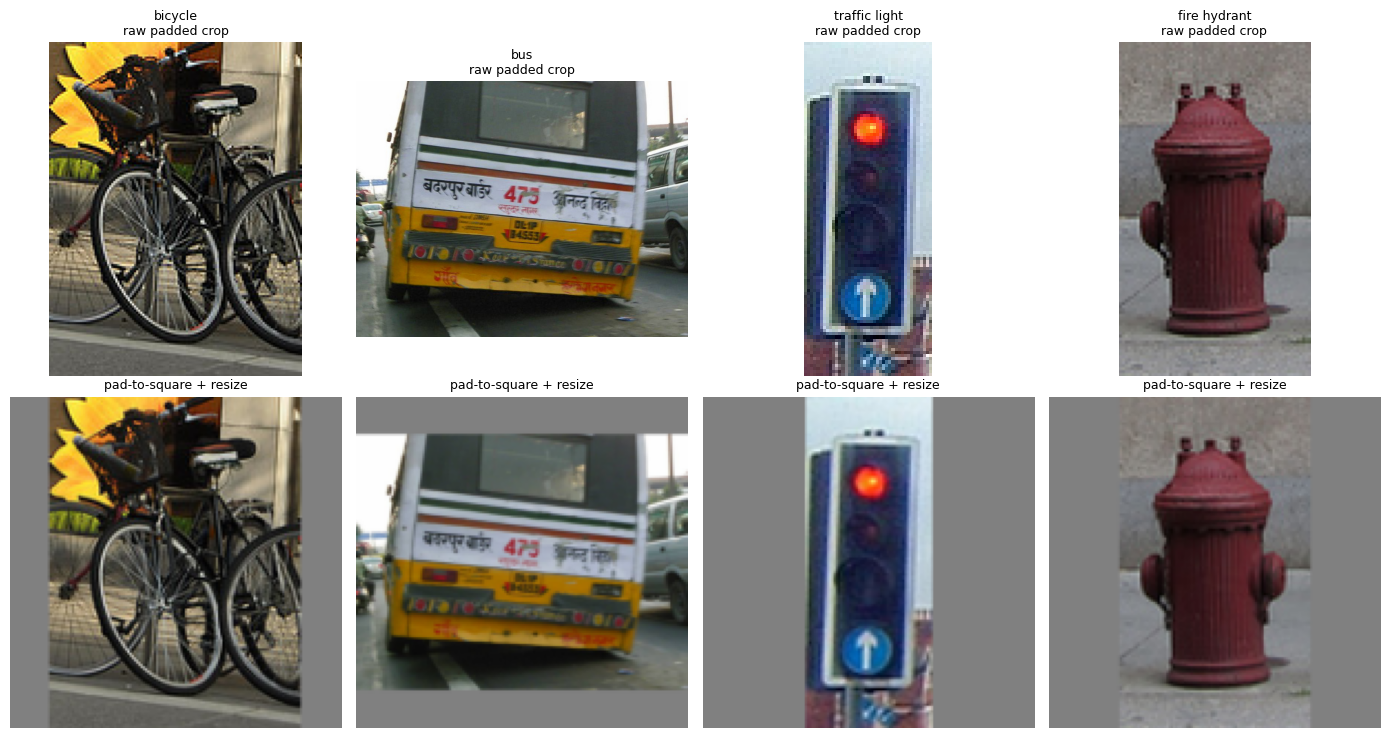

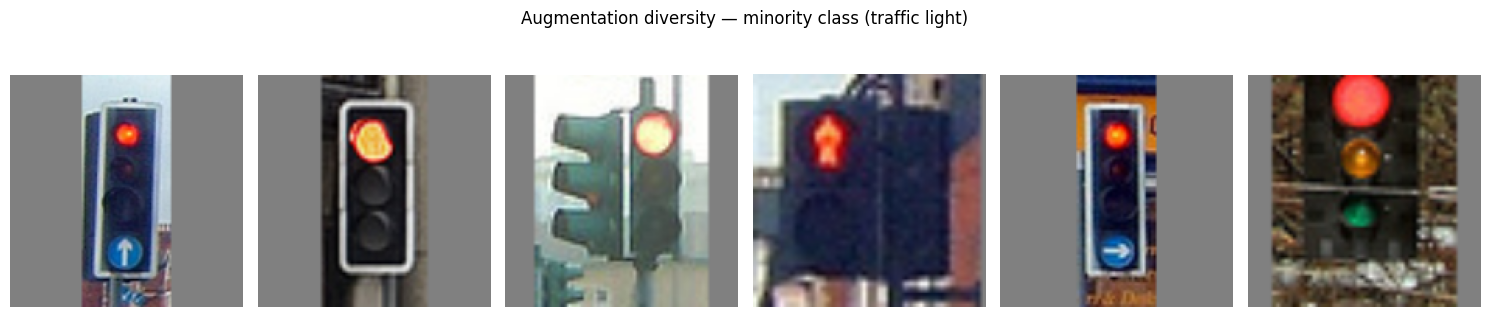

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
for col, cname in enumerate(TARGET_CLASSES):
    raw_im = raw_crops[cname][0][1]
    proc_im = processed_crops[cname][0][1]
    axes[0, col].imshow(raw_im); axes[0, col].set_title(f"{cname}\nraw padded crop", fontsize=9); axes[0, col].axis("off")
    axes[1, col].imshow(proc_im); axes[1, col].set_title("pad-to-square + resize", fontsize=9); axes[1, col].axis("off")
plt.tight_layout()
plt.savefig("preprocess_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

# augmentation diversity, shown on the minority class specifically
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
minority_class = min(processed_crops, key=lambda c: len(processed_crops[c]))
for i, ax in enumerate(axes):
    _, im = balanced_crops[minority_class][i]
    ax.imshow(im); ax.axis("off")
plt.suptitle(f"Augmentation diversity — minority class ({minority_class})", y=1.05)
plt.tight_layout()
plt.savefig("augmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.7 Final preprocessed dataset summary

In [ ]:
final_rows = [{
    "class": c,
    "raw_pulled": len(class_anns[c]),
    "after_quality_filter": len(class_anns_filtered[c]),
    "final_after_augmentation": len(balanced_crops[c]),
} for c in TARGET_CLASSES]
final_df = pd.DataFrame(final_rows)
display(final_df)

fr = final_df["final_after_augmentation"]
print(f"\nFinal imbalance ratio after preprocessing: {fr.max()/fr.min():.2f}x  (was 6.31x on the true Step 1 totals)")

,class,raw_pulled,after_quality_filter,final_after_augmentation
0,bicycle,150,112,140
1,bus,150,140,140
2,traffic light,150,43,140
3,fire hydrant,101,75,140



Final imbalance ratio after preprocessing: 1.00x  (was 6.31x on the true Step 1 totals)


## Step 2 Summary (fill in after running on real Colab output)

- Boxes dropped by the quality filter: *(paste per-class dropped counts here)*
- Final per-class counts after augmentation: *(paste final_df here)*
- Final imbalance ratio: *(paste value here — should be ~1.0x within this subset)*
- Note for the full curation pass: this subset was capped at 150/class in Step 1; the real curation run over the full population (637/316/285/101) should re-target augmentation counts against those true totals, not this exploratory subset's cap.

**Next:** Step 3 (model/algorithm selection) is built directly below.

## Step 3 — Model / Algorithm Selection

**Scope of this pilot.** The real Section 8.2 task is binary per grid-cell classification (target object present / absent), which needs a curated *distractor* (non-target) pool we haven't built yet. Before committing to that larger build, this step runs a cheaper, faster pilot on the 4-class problem we already have fully prepared from Step 2 (bicycle / bus / traffic light / fire hydrant) — same methodology, same conclusions about which algorithm family to trust, at a fraction of the cost. Once an algorithm family is picked here, it carries forward directly to the binary task.

### 3.1 Train / validation / test split — how each is actually used in this pipeline

- **Train** — the only split any model (classical or deep) ever fits its parameters on. It's also the *only* split that gets rebalanced with the Step 2.5 augmentation technique: inflating validation or test with synthetic duplicates would make evaluation numbers look better than the model would actually perform on genuinely new photos.
- **Validation** — used exclusively to choose between the candidate algorithms below (3.4–3.7). None of these numbers get reported as "the accuracy" of the final system — they only decide which single model moves forward.
- **Test** — touched exactly once, in 3.8, on the one algorithm validation selected as best. This is the only number that becomes the project's headline accuracy figure. Looking at test performance any earlier — e.g. to help pick between algorithms — would optimistically bias that number and make it untrustworthy; that's the actual reason for a 3-way split instead of a 2-way one, not just convention.

**Important:** the split below is taken on `processed_crops` — the Step 2.3 output, *before* the Step 2.5 balancing augmentation — and grouped per class before splitting. This guarantees an augmented duplicate of a given source photo can never land in a different split than its original, which would otherwise leak information from train into validation/test and inflate the reported accuracy.

In [ ]:
from sklearn.model_selection import train_test_split

SPLIT_SEED = 42
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

split_data = {"train": {}, "val": {}, "test": {}}
for cname in TARGET_CLASSES:
    items = processed_crops[cname]     # pre-augmentation: Step 2.3 output
    train_items, temp_items = train_test_split(items, train_size=TRAIN_FRAC, random_state=SPLIT_SEED)
    val_items, test_items = train_test_split(
        temp_items, train_size=VAL_FRAC / (VAL_FRAC + TEST_FRAC), random_state=SPLIT_SEED
    )
    split_data["train"][cname] = train_items
    split_data["val"][cname] = val_items
    split_data["test"][cname] = test_items

split_summary = pd.DataFrame([
    {"class": c, "train": len(split_data["train"][c]), "val": len(split_data["val"][c]), "test": len(split_data["test"][c])}
    for c in TARGET_CLASSES
])
display(split_summary)

,class,train,val,test
0,bicycle,78,17,17
1,bus,98,21,21
2,traffic light,30,6,7
3,fire hydrant,52,11,12


### 3.2 Rebalance the training split only

Reuses the exact augmentation technique from Step 2.5 (flip / rotate / brightness / small zoom), applied *only* to `split_data["train"]` — validation and test stay untouched, original, unaugmented crops.

In [ ]:
train_counts_before = {c: len(split_data["train"][c]) for c in TARGET_CLASSES}
TRAIN_TARGET = max(train_counts_before.values())

train_balanced = {}
for cname in TARGET_CLASSES:
    originals = split_data["train"][cname]
    augmented = list(originals)
    aug_i = 0
    while len(augmented) < TRAIN_TARGET:
        base_id, base_im = originals[aug_i % len(originals)]
        aug_im = augment_once(base_im)      # defined in Step 2.5
        augmented.append((f"{base_id}_s3aug{aug_i}", aug_im))
        aug_i += 1
    train_balanced[cname] = augmented
    print(f"{cname:15s} train: {len(originals):3d} -> {len(augmented):3d}  (target {TRAIN_TARGET})")

print("\nval/test sizes are unchanged from Step 3.1 — no augmentation applied to either.")

bicycle         train:  78 ->  98  (target 98)
bus             train:  98 ->  98  (target 98)
traffic light   train:  30 ->  98  (target 98)
fire hydrant    train:  52 ->  98  (target 98)

val/test sizes are unchanged from Step 3.1 — no augmentation applied to either.


### 3.3 Feature extraction for the classical ML candidates

Classical models don't consume raw pixels well, so we hand-engineer a feature vector: **HOG (Histogram of Oriented Gradients)**, a standard, well-established shape/edge descriptor for classical computer vision — a defensible, explainable choice for a baseline, as opposed to something arbitrary like raw flattened pixels.

In [ ]:
from skimage.feature import hog
from skimage.color import rgb2gray

def extract_hog_features(pil_image):
    gray = rgb2gray(np.asarray(pil_image))
    return hog(gray, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), feature_vector=True)

def build_xy(split_dict):
    X, y = [], []
    for cname in TARGET_CLASSES:
        for _id, im in split_dict[cname]:
            X.append(extract_hog_features(im))
            y.append(cname)
    return np.array(X), np.array(y)

X_train, y_train = build_xy(train_balanced)
X_val, y_val     = build_xy(split_data["val"])
X_test, y_test   = build_xy(split_data["test"])
print("HOG feature vector length:", X_train.shape[1])
print(f"train/val/test sizes: {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]}")

HOG feature vector length: 2304
train/val/test sizes: 392 / 55 / 57


### 3.4 Candidate algorithms — classical ML

- **Logistic Regression** — simplest possible baseline; a linear decision boundary over HOG features. Fast, fully interpretable, but can only separate classes that are linearly separable in HOG space.
- **Random Forest** — an ensemble of decision trees; handles non-linear feature interactions HOG alone can't express, and is fairly robust with small, imbalanced data (relevant given Step 1/2's imbalance findings).
- **SVM (RBF kernel)** — typically the strongest classical option for hand-crafted features like HOG on a small dataset, since the kernel trick captures non-linear boundaries without needing much data.
- **k-NN** — a non-parametric baseline; useful as a sanity check ("are the classes even separable in this feature space at all?") but usually the weakest of the four on real photos.

**Expected pattern, before running:** SVM ≳ Random Forest > Logistic Regression > k-NN — but all four are expected to trail the deep-learning candidates below, since none of them can learn features directly from pixels the way a CNN can.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

scaler = StandardScaler().fit(X_train)
X_train_s, X_val_s, X_test_s = scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)

classical_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=SPLIT_SEED),
    "SVM (RBF)":           SVC(kernel="rbf", C=10, gamma="scale"),
    "k-NN (k=5)":          KNeighborsClassifier(n_neighbors=5),
}

results = []
model_registry = {}   # name -> ("classical", fitted_estimator) or ("torch", trained_model)

for name, clf in classical_models.items():
    clf.fit(X_train_s, y_train)
    preds = clf.predict(X_val_s)
    acc, f1 = accuracy_score(y_val, preds), f1_score(y_val, preds, average="macro")
    results.append({"model": name, "type": "Classical ML", "val_accuracy": acc, "val_macro_f1": f1})
    model_registry[name] = ("classical", clf)
    print(f"{name:22s} val_acc={acc:.3f}  val_macro_f1={f1:.3f}")

Logistic Regression    val_acc=0.782  val_macro_f1=0.774
Random Forest          val_acc=0.727  val_macro_f1=0.696
SVM (RBF)              val_acc=0.836  val_macro_f1=0.842
k-NN (k=5)             val_acc=0.764  val_macro_f1=0.750


### 3.5 Candidate algorithms — deep learning

- **Small CNN, trained from scratch** — learns spatial/visual features directly from pixels rather than relying on hand-crafted HOG features, in the same spirit as Part 1's CaptchaResNet. The risk: our train split (roughly 90–140 images per class *before* augmentation, per 3.1) is small for training a CNN's parameters from random initialization — real risk of overfitting.
- **Transfer learning (MobileNetV2, ImageNet-pretrained)** — reuses visual features already learned from ~1.28M ImageNet photos, and only fits a small classifier head on top. This is the standard, literature-backed choice specifically *because* our labeled dataset is small — expected to be the strongest candidate here.

**Expected ranking, before running:** transfer learning > classical ML > from-scratch CNN. The reasoning: transfer learning needs the least new data to work well (it starts from already-learned features), classical ML with engineered features needs a moderate amount, and a CNN trained fully from scratch on this few hundred images per class needs the most — more than we currently have at this exploratory-subset stage.

### 3.6 Small CNN, trained from scratch

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

class CropDataset(Dataset):
    def __init__(self, split_dict):
        self.items = [(im, CLASS_TO_IDX[cname]) for cname in TARGET_CLASSES for _id, im in split_dict[cname]]
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        im, label = self.items[idx]
        arr = normalize_for_cnn(im, standardize=True)      # defined in Step 2.4
        return torch.from_numpy(arr.transpose(2, 0, 1)).float(), label

train_loader = DataLoader(CropDataset(train_balanced), batch_size=16, shuffle=True)
val_loader   = DataLoader(CropDataset(split_data["val"]), batch_size=32, shuffle=False)
test_loader  = DataLoader(CropDataset(split_data["test"]), batch_size=32, shuffle=False)
print(f"train/val/test dataset sizes: {len(train_loader.dataset)} / {len(val_loader.dataset)} / {len(test_loader.dataset)}")

def train_torch_model(model, train_loader, val_loader, epochs, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            preds_all.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            labels_all.extend(yb.numpy())
    return accuracy_score(labels_all, preds_all), f1_score(labels_all, preds_all, average="macro")

class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, num_classes)
    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

small_cnn = SmallCNN(num_classes=len(TARGET_CLASSES))
acc, f1 = train_torch_model(small_cnn, train_loader, val_loader, epochs=10)
results.append({"model": "Small CNN (from scratch)", "type": "Deep Learning", "val_accuracy": acc, "val_macro_f1": f1})
model_registry["Small CNN (from scratch)"] = ("torch", small_cnn)
print(f"Small CNN (from scratch)  val_acc={acc:.3f}  val_macro_f1={f1:.3f}")

Using device: cpu
train/val/test dataset sizes: 392 / 55 / 57
Small CNN (from scratch)  val_acc=0.691  val_macro_f1=0.668


### 3.7 Transfer learning — MobileNetV2 (ImageNet-pretrained)

In [ ]:
from torchvision import models

def build_transfer_model(num_classes):
    backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    for p in backbone.parameters():
        p.requires_grad = False          # freeze the pretrained feature extractor
    backbone.classifier[1] = nn.Linear(backbone.last_channel, num_classes)   # only this head trains
    return backbone

transfer_model = build_transfer_model(len(TARGET_CLASSES))
acc, f1 = train_torch_model(transfer_model, train_loader, val_loader, epochs=8)
results.append({"model": "MobileNetV2 (transfer learning)", "type": "Deep Learning", "val_accuracy": acc, "val_macro_f1": f1})
model_registry["MobileNetV2 (transfer learning)"] = ("torch", transfer_model)
print(f"MobileNetV2 (transfer learning)  val_acc={acc:.3f}  val_macro_f1={f1:.3f}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 61.5MB/s]


MobileNetV2 (transfer learning)  val_acc=0.909  val_macro_f1=0.897


### 3.8 Comparison (validation) and final test-set result

The table/chart below rank every candidate on **validation** — this is where the algorithm choice gets made. Only the single winner is then evaluated on **test**, exactly once, for the number that actually goes in the paper.

,model,type,val_accuracy,val_macro_f1
0,MobileNetV2 (transfer learning),Deep Learning,0.909091,0.897254
1,SVM (RBF),Classical ML,0.836364,0.842100
2,Logistic Regression,Classical ML,0.781818,0.773677
3,k-NN (k=5),Classical ML,0.763636,0.750213
4,Random Forest,Classical ML,0.727273,0.695810
5,Small CNN (from scratch),Deep Learning,0.690909,0.668197


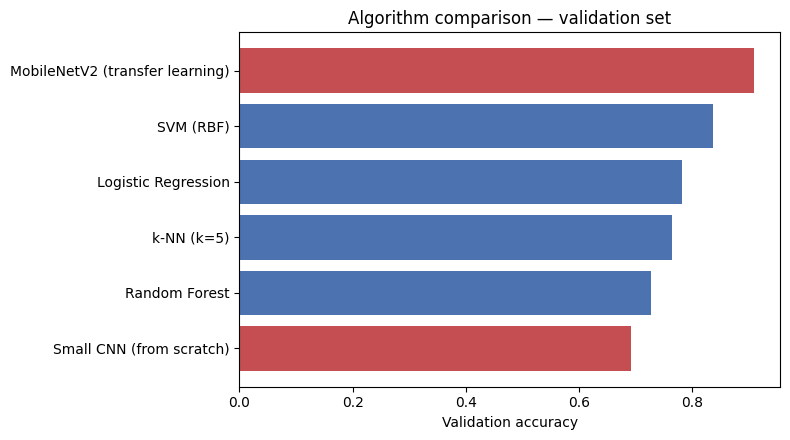

In [ ]:
results_df = pd.DataFrame(results).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
display(results_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#4C72B0" if t == "Classical ML" else "#C44E52" for t in results_df["type"]]
ax.barh(results_df["model"], results_df["val_accuracy"], color=colors)
ax.set_xlabel("Validation accuracy")
ax.set_title("Algorithm comparison — validation set")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("algorithm_comparison.png", dpi=150)
plt.show()

Best model on validation: MobileNetV2 (transfer learning)  ->  evaluating on TEST now (touched exactly once)

FINAL TEST RESULT — MobileNetV2 (transfer learning): accuracy=0.965, macro-F1=0.953


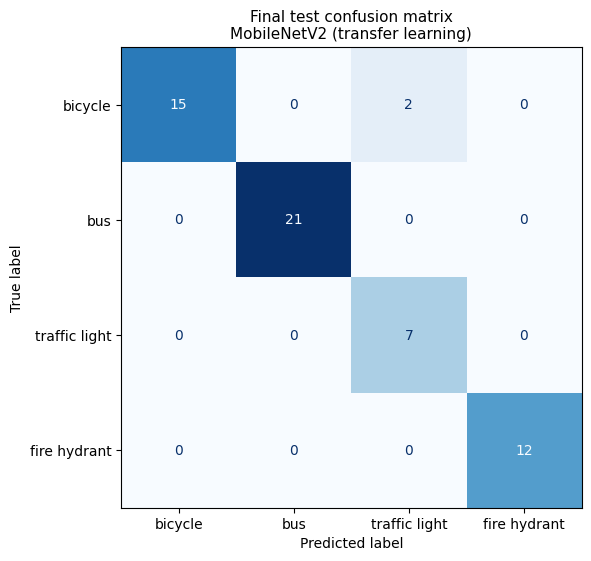

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_name = results_df.iloc[0]["model"]
kind, model_obj = model_registry[best_name]
print(f"Best model on validation: {best_name}  ->  evaluating on TEST now (touched exactly once)")

def predict_test(kind, model_obj):
    if kind == "classical":
        return list(y_test), list(model_obj.predict(X_test_s))
    model_obj.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds_all.extend(model_obj(xb.to(device)).argmax(1).cpu().numpy())
            labels_all.extend(yb.numpy())
    return [IDX_TO_CLASS[i] for i in labels_all], [IDX_TO_CLASS[i] for i in preds_all]

y_true, y_pred = predict_test(kind, model_obj)
test_acc = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"\nFINAL TEST RESULT — {best_name}: accuracy={test_acc:.3f}, macro-F1={test_f1:.3f}")

cm = confusion_matrix(y_true, y_pred, labels=TARGET_CLASSES)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm, display_labels=TARGET_CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Final test confusion matrix\n{best_name}", fontsize=11)
plt.tight_layout()
plt.savefig("final_test_confusion_matrix.png", dpi=150)
plt.show()

## Step 3 Summary (fill in after running on real Colab output)

- Validation ranking of all 6 candidates: *(paste results_df here)*
- Did the actual ranking match the "expected ranking" reasoning in 3.5 (transfer learning > classical ML > from-scratch CNN)? *(note here — if not, that's worth a sentence in the paper too)*
- Chosen algorithm: *(paste best_name here)*
- Final, one-time test accuracy / macro-F1: *(paste test_acc / test_f1 here)*
- Where the confusion matrix shows the most mistakes, if any: *(note here)*

**Note:** this pilot used the 4-class target-only problem. Carrying the winning algorithm family into Section 8.2's actual binary target/non-target grid-cell classifier requires curating a distractor (non-target) pool first — that's the next scoped piece of work, not part of this notebook yet.

**Next:** Step 4 (distractor curation, the real grid-CAPTCHA generator, and the real Section 8.2 classifier) is built directly below.

## Step 4 — Grid-CAPTCHA Generator & the Real Section 8.2 Classifier

This is the actual deliverable Section 8.1 specified — "a reusable grid-CAPTCHA generator producing (image_grid, target_class, ground_truth_cell_mask) triples" — plus the real Section 8.2 baseline classifier, now that we have a distractor pool to train it against. It reuses everything already validated: the Step 2 crop pipeline and the winning architecture from Step 3 (MobileNetV2 transfer learning) — no re-litigating the algorithm choice.

### 4.1 Distractor (non-target) class curation

Six COCO classes chosen as distractors: **car, person, dog, umbrella, backpack, bench**. Reasoning — all plausible in real street-scene photos (matching reCAPTCHA's actual visual context), all visually distinct enough from our 4 targets to avoid label ambiguity, and all reasonably well-represented in COCO val2017.

In [ ]:
DISTRACTOR_CLASSES = ["car", "person", "dog", "umbrella", "backpack", "bench"]

distractor_cat_ids = {c: coco.getCatIds(catNms=[c])[0] for c in DISTRACTOR_CLASSES}
distractor_true_totals, distractor_anns, distractor_imgs = {}, {}, {}

print("True total instances available in COCO val2017 for distractor classes:")
for cname, cid in distractor_cat_ids.items():
    all_ann_ids = coco.getAnnIds(catIds=[cid])
    distractor_true_totals[cname] = len(all_ann_ids)
    anns = coco.loadAnns(all_ann_ids)
    distractor_anns[cname] = anns[:MAX_PER_CLASS]
    distractor_imgs[cname] = sorted({a["image_id"] for a in distractor_anns[cname]})
    print(f"  {cname:10s}: {distractor_true_totals[cname]:5d} true total, pulling {len(distractor_anns[cname])}")

needed_distractor_img_ids = sorted({iid for ids in distractor_imgs.values() for iid in ids})
print(f"\nDownloading {len(needed_distractor_img_ids)} unique distractor images...")
for iid in needed_distractor_img_ids:
    info = coco.loadImgs(iid)[0]
    fpath = IMG_DIR / info["file_name"]
    if not fpath.exists():
        r = requests.get(f"http://images.cocodataset.org/val2017/{info['file_name']}", timeout=15)
        if r.status_code == 200:
            fpath.write_bytes(r.content)
print("Done.")

True total instances available in COCO val2017 for distractor classes:
  car       :  1932 true total, pulling 150
  person    : 11004 true total, pulling 150
  dog       :   218 true total, pulling 150
  umbrella  :   413 true total, pulling 150
  backpack  :   371 true total, pulling 150
  bench     :   413 true total, pulling 150

Done.


### 4.2 Preprocess distractors through the exact same Step 2 pipeline

Reuses `padded_crop` and `pad_to_square_then_resize` (defined in Step 2.2/2.3) so distractor crops are pixel-for-pixel consistent with target crops — same quality filter, same padding, same letterbox-to-square, same final 150×150 size.

In [ ]:
distractor_processed = {}
for cname in DISTRACTOR_CLASSES:
    kept_anns = [a for a in distractor_anns[cname]
                 if a["area"] >= MIN_AREA and min(a["bbox"][2], a["bbox"][3]) >= MIN_SIDE]
    crops = []
    for ann in kept_anns:
        info = coco.loadImgs(ann["image_id"])[0]
        im = Image.open(IMG_DIR / info["file_name"]).convert("RGB")
        crop = padded_crop(im, ann["bbox"], PAD_FRACTION)
        proc = pad_to_square_then_resize(crop, CELL_SIZE)
        crops.append((ann["id"], proc))
    distractor_processed[cname] = crops
    print(f"{cname:10s}: {len(kept_anns)}/{len(distractor_anns[cname])} kept after quality filter -> {len(crops)} processed crops")

all_distractor_crops = [im for cname in DISTRACTOR_CLASSES for _id, im in distractor_processed[cname]]
print(f"\nTotal distractor pool: {len(all_distractor_crops)} crops across {len(DISTRACTOR_CLASSES)} classes")

car       : 113/150 kept after quality filter -> 113 processed crops
person    : 125/150 kept after quality filter -> 125 processed crops
dog       : 141/150 kept after quality filter -> 141 processed crops
umbrella  : 116/150 kept after quality filter -> 116 processed crops
backpack  : 65/150 kept after quality filter -> 65 processed crops
bench     : 128/150 kept after quality filter -> 128 processed crops

Total distractor pool: 688 crops across 6 classes


### 4.3 The grid-CAPTCHA generator

For a given `target_class`, assembles a 3×3 grid where 2-4 cells (random, per the report's spec) contain a crop of the target class, and the rest are distractors. Distractors are drawn from *both* the six true distractor classes *and* crops from the other three target classes — realistic "false-friend" distractors, since a real "select all buses" challenge often shows bicycles or traffic lights as decoys, not just random unrelated objects.

In [ ]:
from PIL import ImageDraw
import random as pyrandom

def generate_grid_captcha(target_class, target_pool_by_class, distractor_pool, grid_size=3, cell_size=CELL_SIZE, rng=None):
    rng = rng or pyrandom
    n_cells = grid_size * grid_size
    num_target_cells = rng.randint(2, 4)
    target_positions = set(rng.sample(range(n_cells), num_target_cells))

    other_target_crops = [im for c in TARGET_CLASSES if c != target_class for _id, im in target_pool_by_class[c]]
    full_distractor_pool = distractor_pool + other_target_crops
    target_crops_available = [im for _id, im in target_pool_by_class[target_class]]

    cell_images, target_mask = [], []
    for i in range(n_cells):
        if i in target_positions:
            cell_images.append(rng.choice(target_crops_available))
            target_mask.append(True)
        else:
            cell_images.append(rng.choice(full_distractor_pool))
            target_mask.append(False)

    canvas = Image.new("RGB", (cell_size * grid_size, cell_size * grid_size), (255, 255, 255))
    for i, cell_im in enumerate(cell_images):
        row, col = divmod(i, grid_size)
        canvas.paste(cell_im, (col * cell_size, row * cell_size))
    draw = ImageDraw.Draw(canvas)
    for k in range(1, grid_size):
        draw.line([(0, k * cell_size), (cell_size * grid_size, k * cell_size)], fill=(255, 255, 255), width=3)
        draw.line([(k * cell_size, 0), (k * cell_size, cell_size * grid_size)], fill=(255, 255, 255), width=3)

    return canvas, cell_images, target_mask

print("Generator defined. Signature: generate_grid_captcha(target_class, target_pool_by_class, distractor_pool) "
      "-> (grid_image, cell_images[9], target_mask[9])")

Generator defined. Signature: generate_grid_captcha(target_class, target_pool_by_class, distractor_pool) -> (grid_image, cell_images[9], target_mask[9])


### 4.4 Sample generated CAPTCHAs (one per target class)

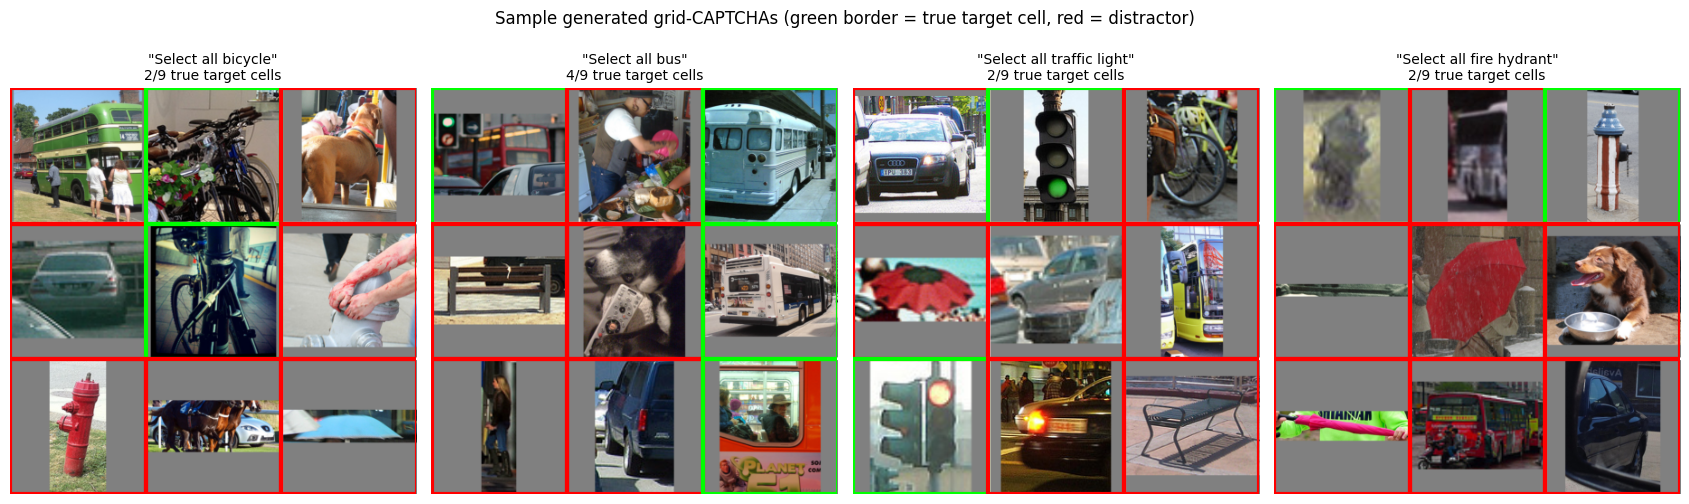

In [ ]:
pyrandom.seed(123)
fig, axes = plt.subplots(1, 4, figsize=(17, 5))
for ax, tclass in zip(axes, TARGET_CLASSES):
    grid_img, cell_imgs, mask = generate_grid_captcha(tclass, processed_crops, all_distractor_crops, rng=pyrandom)
    ax.imshow(grid_img)
    for i, is_target in enumerate(mask):
        row, col = divmod(i, 3)
        color = "lime" if is_target else "red"
        ax.add_patch(patches.Rectangle((col * CELL_SIZE, row * CELL_SIZE), CELL_SIZE, CELL_SIZE,
                                        linewidth=3, edgecolor=color, facecolor="none"))
    ax.set_title(f'"Select all {tclass}"\n{sum(mask)}/9 true target cells', fontsize=10)
    ax.axis("off")
plt.suptitle("Sample generated grid-CAPTCHAs (green border = true target cell, red = distractor)", y=1.03)
plt.tight_layout()
plt.savefig("sample_grid_captchas.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.5 The real Section 8.2 classifier — 5-way (4 targets + distractor)

Extends Step 3's exact methodology (same 70/15/15 split taken before augmentation, augmentation applied only to train, same winning architecture) to a 5th class, "distractor," so the classifier can actually tell target objects apart from everything else — not just tell the 4 targets apart from each other like the Step 3 pilot did.

In [ ]:
ALL_CLASSES = TARGET_CLASSES + ["distractor"]
CLASS_TO_IDX_5 = {c: i for i, c in enumerate(ALL_CLASSES)}
IDX_TO_CLASS_5 = {i: c for c, i in CLASS_TO_IDX_5.items()}

distractor_pool_items = [(f"{cname}_{aid}", im) for cname in DISTRACTOR_CLASSES for aid, im in distractor_processed[cname]]
distr_train, distr_temp = train_test_split(distractor_pool_items, train_size=TRAIN_FRAC, random_state=SPLIT_SEED)
distr_val, distr_test = train_test_split(distr_temp, train_size=VAL_FRAC / (VAL_FRAC + TEST_FRAC), random_state=SPLIT_SEED)

split_data_5 = {
    "train": {**split_data["train"], "distractor": distr_train},
    "val":   {**split_data["val"],   "distractor": distr_val},
    "test":  {**split_data["test"],  "distractor": distr_test},
}
display(pd.DataFrame([{"class": c, "train": len(split_data_5["train"][c]), "val": len(split_data_5["val"][c]),
                        "test": len(split_data_5["test"][c])} for c in ALL_CLASSES]))

train_target_5 = max(len(v) for v in split_data_5["train"].values())
train_balanced_5 = {}
for cname in ALL_CLASSES:
    originals = split_data_5["train"][cname]
    augmented = list(originals)
    aug_i = 0
    while len(augmented) < train_target_5:
        base_id, base_im = originals[aug_i % len(originals)]
        aug_im = augment_once(base_im)
        augmented.append((f"{base_id}_s4aug{aug_i}", aug_im))
        aug_i += 1
    train_balanced_5[cname] = augmented
    print(f"{cname:15s} train: {len(originals):3d} -> {len(augmented):3d}  (target {train_target_5})")

,class,train,val,test
0,bicycle,78,17,17
1,bus,98,21,21
2,traffic light,30,6,7
3,fire hydrant,52,11,12
4,distractor,481,103,104


bicycle         train:  78 -> 481  (target 481)
bus             train:  98 -> 481  (target 481)
traffic light   train:  30 -> 481  (target 481)
fire hydrant    train:  52 -> 481  (target 481)
distractor      train: 481 -> 481  (target 481)


In [ ]:
class CropDataset5(Dataset):
    def __init__(self, split_dict):
        self.items = [(im, CLASS_TO_IDX_5[cname]) for cname in ALL_CLASSES for _id, im in split_dict[cname]]
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        im, label = self.items[idx]
        arr = normalize_for_cnn(im, standardize=True)
        return torch.from_numpy(arr.transpose(2, 0, 1)).float(), label

train_loader_5 = DataLoader(CropDataset5(train_balanced_5), batch_size=16, shuffle=True)
val_loader_5   = DataLoader(CropDataset5(split_data_5["val"]), batch_size=32, shuffle=False)
test_loader_5  = DataLoader(CropDataset5(split_data_5["test"]), batch_size=32, shuffle=False)
print(f"5-way dataset sizes: {len(train_loader_5.dataset)} / {len(val_loader_5.dataset)} / {len(test_loader_5.dataset)}")

classifier_5way = build_transfer_model(len(ALL_CLASSES))    # same architecture Step 3 selected as best
acc5, f1_5 = train_torch_model(classifier_5way, train_loader_5, val_loader_5, epochs=8)
print(f"\n5-way classifier (targets + distractor)  val_acc={acc5:.3f}  val_macro_f1={f1_5:.3f}")

5-way dataset sizes: 2405 / 158 / 161

5-way classifier (targets + distractor)  val_acc=0.892  val_macro_f1=0.835


5-way classifier FINAL TEST RESULT: accuracy=0.901, macro-F1=0.864


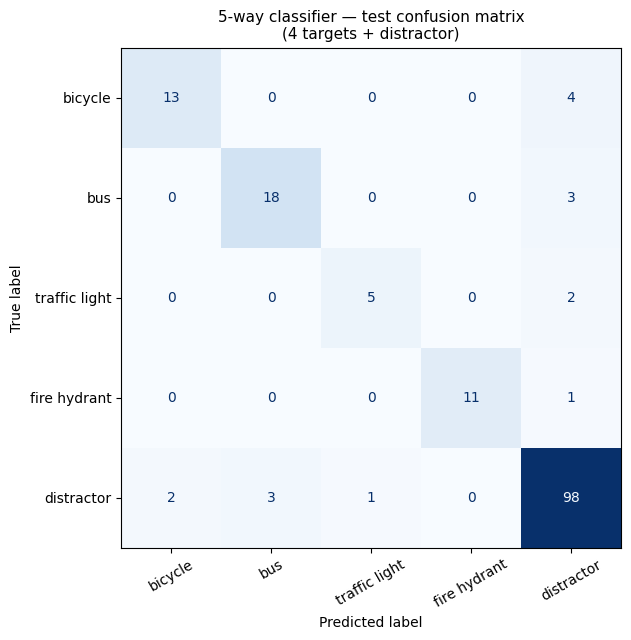

In [ ]:
def predict_test_5(model):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for xb, yb in test_loader_5:
            preds_all.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            labels_all.extend(yb.numpy())
    return [IDX_TO_CLASS_5[i] for i in labels_all], [IDX_TO_CLASS_5[i] for i in preds_all]

y_true_5, y_pred_5 = predict_test_5(classifier_5way)
test_acc_5 = accuracy_score(y_true_5, y_pred_5)
test_f1_5 = f1_score(y_true_5, y_pred_5, average="macro")
print(f"5-way classifier FINAL TEST RESULT: accuracy={test_acc_5:.3f}, macro-F1={test_f1_5:.3f}")

cm5 = confusion_matrix(y_true_5, y_pred_5, labels=ALL_CLASSES)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ConfusionMatrixDisplay(cm5, display_labels=ALL_CLASSES).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30)
ax.set_title("5-way classifier — test confusion matrix\n(4 targets + distractor)", fontsize=11)
plt.tight_layout()
plt.savefig("classifier_5way_confusion_matrix.png", dpi=150)
plt.show()

### 4.6 End-to-end evaluation — the real, comparable number

This is what actually compares to published reCAPTCHA-breaking results: generate full grid CAPTCHAs, run the classifier on every cell, and measure whether it gets the **whole grid** right — not just per-cell accuracy. This is the same standard Hossen et al. (USENIX RAID 2020) reported **83.25%** on for real reCAPTCHA v2 (see prior discussion). This is still not a fully fair comparison — our grids are synthetically assembled from clean COCO crops, not real (possibly compressed/degraded) reCAPTCHA imagery — but it's a genuine grid-level solve-rate number for the first time, not just a per-object classification accuracy.

In [ ]:
def predict_cell_class(model, pil_image):
    model.eval()
    arr = normalize_for_cnn(pil_image, standardize=True)
    tensor = torch.from_numpy(arr.transpose(2, 0, 1)).float().unsqueeze(0).to(device)
    with torch.no_grad():
        pred_idx = model(tensor).argmax(1).item()
    return IDX_TO_CLASS_5[pred_idx]

pyrandom.seed(2024)
N_EVAL_GRIDS = 60
records = []
per_cell_correct, per_cell_total, solved_grids = 0, 0, 0

for _ in range(N_EVAL_GRIDS):
    tclass = pyrandom.choice(TARGET_CLASSES)
    grid_img, cell_imgs, mask = generate_grid_captcha(tclass, processed_crops, all_distractor_crops, rng=pyrandom)
    predicted_mask = [predict_cell_class(classifier_5way, cell) == tclass for cell in cell_imgs]
    correct_cells = sum(p == m for p, m in zip(predicted_mask, mask))
    per_cell_correct += correct_cells
    per_cell_total += len(mask)
    grid_solved = predicted_mask == mask
    solved_grids += int(grid_solved)
    records.append({"target_class": tclass, "cells_correct": correct_cells, "grid_solved": grid_solved})

grid_eval_df = pd.DataFrame(records)
per_cell_acc = per_cell_correct / per_cell_total
grid_solve_rate = solved_grids / N_EVAL_GRIDS

print(f"Per-cell accuracy across {N_EVAL_GRIDS} generated CAPTCHAs: {per_cell_acc:.3f}")
print(f"Full-grid solve rate (ALL 9 cells correct): {grid_solve_rate:.3f}  ({solved_grids}/{N_EVAL_GRIDS})")
print(f"\nFor reference: Hossen et al. (USENIX RAID 2020) reported an 83.25% real-world reCAPTCHA v2 solve rate")
print("using an object-detection solver trained on similar categories (bus, traffic light, crosswalk, car, fire hydrant).")

display(grid_eval_df.groupby("target_class")["grid_solved"].mean().rename("per-class grid solve rate"))

Per-cell accuracy across 60 generated CAPTCHAs: 0.978
Full-grid solve rate (ALL 9 cells correct): 0.800  (48/60)

For reference: Hossen et al. (USENIX RAID 2020) reported an 83.25% real-world reCAPTCHA v2 solve rate
using an object-detection solver trained on similar categories (bus, traffic light, crosswalk, car, fire hydrant).


,per-class grid solve rate
target_class,
bicycle,0.818182
bus,0.785714
fire hydrant,0.888889
traffic light,0.705882


## Step 4 Summary (fill in after running on real Colab output)

- Distractor pool size / classes: *(paste from 4.1/4.2 here)*
- 5-way classifier validation / test accuracy: *(paste acc5 / test_acc_5 here)*
- Where the 5-way confusion matrix shows the most confusion (e.g. distractor mistaken for a target, or vice versa): *(note here)*
- Grid-level solve rate over the evaluation sample: *(paste grid_solve_rate here)*
- How that compares to Hossen et al.'s 83.25% real-world benchmark, with the caveat that our grids use clean synthetic crops rather than real degraded reCAPTCHA imagery: *(note here)*

**What Section 8.1 and the preliminary part of 8.2 now cover:** dataset verified and corrected, full EDA, a validated preprocessing pipeline, a working grid-CAPTCHA generator producing (image_grid, target_class, ground_truth_cell_mask) triples as specified, a trained 5-way baseline classifier, and a first genuine grid-level solve-rate number.

**Still not built (unchanged from before):** the CLIP embedding pipeline (8.3), the dual-objective CNN+CLIP hardening algorithm — the project's actual novelty claim (8.4), the vanilla-PGD-only baseline (8.5), the multi-attacker evaluation across CNN/open VLM/commercial VLM/humans (8.6), and the human usability study (8.7).

**Next (not built yet):** Section 8.3 — integrate a frozen pretrained CLIP model as a fixed feature extractor, the first step toward the dual-objective hardening algorithm that is this project's central contribution.

In [2]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [3]:
!git clone https://github.com/albinm2004/CAPTCHA-Security-Adversarial-Robustness-and-VLM-Resistant-Hardening-of-Image-Based-CAPTCHAs.git
%cd CAPTCHA-Security-Adversarial-Robustness-and-VLM-Resistant-Hardening-of-Image-Based-CAPTCHAs
!git status

Cloning into 'CAPTCHA-Security-Adversarial-Robustness-and-VLM-Resistant-Hardening-of-Image-Based-CAPTCHAs'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/CAPTCHA-Security-Adversarial-Robustness-and-VLM-Resistant-Hardening-of-Image-Based-CAPTCHAs
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


## Step 5 — Stage 8.3: The CLIP Zero-Shot Attacker

This adds the project's **second attacker**: CLIP (Contrastive Language–Image
Pretraining), used zero-shot as a stand-in for a Vision-Language-Model (VLM)
bot — the "smart AI bot" category from the Part 2 report. Unlike the Step 4
CNN, which only knows the 5 labels it was trained on (4 targets + a generic
"distractor" bucket), CLIP is given the *real* candidate object names —
the 4 target classes plus the 6 actual distractor classes from Step 4.1
(car, person, dog, umbrella, backpack, bench) — and picks whichever text
prompt each cell image matches best. That is a more realistic zero-shot
setup than reusing the CNN's artificial "distractor" label, and it's how an
actual VLM-based CAPTCHA solver would approach the same grid: it never
sees a "distractor" class, it just judges "does this look like a bicycle?"
against every plausible label.

Everything below reuses Step 1–4 objects directly (`TARGET_CLASSES`,
`DISTRACTOR_CLASSES`, `processed_crops`, `distractor_processed`,
`all_distractor_crops`, `generate_grid_captcha`, `CELL_SIZE`) — run this
notebook top-to-bottom in Colab, same as before; Stage 8.3 does not
re-download or re-process anything.

**Network note:** this section needs real internet access to pull the
pretrained CLIP checkpoint (from the `open_clip` / HuggingFace hub, or
OpenAI's original weights) — same as Step 1 needed it for COCO. Run it in
Colab, not in a network-restricted environment; a locked-down sandbox
without a path to those weight hosts cannot execute this cell for real
(that's exactly the situation this stage was drafted under — see the
project notes for what that means for today's numbers).

### 5.1 — Load a pretrained CLIP checkpoint

In [ ]:
!pip install -q open_clip_torch

import open_clip
import torch

CLIP_MODEL_NAME = "ViT-B-32"
CLIP_PRETRAINED = "openai"   # OpenAI's original CLIP weights, loaded via open_clip's hub integration

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED)
clip_tokenizer = open_clip.get_tokenizer(CLIP_MODEL_NAME)
clip_model.eval().to(device)   # `device` was set in Step 3.6

CLIP_EMBED_DIM = clip_model.visual.output_dim if hasattr(clip_model.visual, "output_dim") else 512
print(f"Loaded {CLIP_MODEL_NAME} ({CLIP_PRETRAINED}) on {device}, embedding dim {CLIP_EMBED_DIM}")

### 5.2 — Candidate labels and text-prompt encoding

Text embeddings only need to be computed once per class name (there are far
fewer classes than images), so they aren't part of the image-embedding
cache in 5.3 — they're just held in `text_features` for the rest of this
notebook.

In [ ]:
CLIP_PROMPT_TEMPLATE = "a photo of a {}"

# Real object names, not the CNN's artificial "distractor" bucket — see the
# Step 5 intro for why this is the fairer zero-shot setup.
CANDIDATE_LABELS = TARGET_CLASSES + DISTRACTOR_CLASSES

with torch.no_grad():
    text_tokens = clip_tokenizer([CLIP_PROMPT_TEMPLATE.format(c) for c in CANDIDATE_LABELS]).to(device)
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print(f"Encoded {len(CANDIDATE_LABELS)} candidate labels: {CANDIDATE_LABELS}")

### 5.3 — Embedding extraction and caching

Every image that can appear in a generated grid gets its CLIP embedding
computed exactly once and cached — both in memory (keyed by the live PIL
object, since `generate_grid_captcha` hands back references into these
same pools) and on disk (keyed by a stable id, so Stage 8.4/8.5's PGD
engine and Stage 8.6's evaluation matrix can reuse this cache across
separate notebook runs instead of recomputing embeddings from scratch).

In [ ]:
import numpy as np
import pickle
from pathlib import Path

CLIP_CACHE_PATH = Path("coco_subset/clip_embeddings_cache.pkl")

# stable_id -> embedding (numpy array), persisted to disk
clip_disk_cache = {}
if CLIP_CACHE_PATH.exists():
    with open(CLIP_CACHE_PATH, "rb") as f:
        clip_disk_cache = pickle.load(f)
    print(f"Loaded {len(clip_disk_cache)} cached embeddings from {CLIP_CACHE_PATH}")

# id(PIL.Image) -> embedding (torch tensor, on `device`), for this run only —
# lets clip_predict_cell_class() look up any cell image generate_grid_captcha hands it
clip_live_cache = {}

@torch.no_grad()
def _embed_pil(pil_image):
    tensor = clip_preprocess(pil_image).unsqueeze(0).to(device)
    emb = clip_model.encode_image(tensor)
    return (emb / emb.norm(dim=-1, keepdim=True)).squeeze(0)

def embed_and_cache(stable_id, pil_image):
    """Compute (or reuse) the embedding for one image, updating both caches."""
    if stable_id in clip_disk_cache:
        emb = torch.from_numpy(clip_disk_cache[stable_id]).to(device)
    else:
        emb = _embed_pil(pil_image)
        clip_disk_cache[stable_id] = emb.cpu().numpy()
    clip_live_cache[id(pil_image)] = emb
    return emb

print("Embedding every target crop, distractor crop, and augmented crop used anywhere downstream...")
n_embedded = 0
for cname in TARGET_CLASSES:
    for ann_id, im in processed_crops[cname]:
        embed_and_cache(f"target:{cname}:{ann_id}", im)
        n_embedded += 1
for cname in DISTRACTOR_CLASSES:
    for ann_id, im in distractor_processed[cname]:
        embed_and_cache(f"distractor:{cname}:{ann_id}", im)
        n_embedded += 1

with open(CLIP_CACHE_PATH, "wb") as f:
    pickle.dump(clip_disk_cache, f)

print(f"Embedded {n_embedded} unique crops ({len(clip_disk_cache)} total in disk cache) -> {CLIP_CACHE_PATH}")

### 5.4 — CLIP zero-shot classifier

In [ ]:
def clip_predict_cell_class(pil_image):
    """Zero-shot CLIP prediction for one grid cell. Mirrors predict_cell_class()
    from Step 4.6 so the two attackers are evaluated identically."""
    emb = clip_live_cache.get(id(pil_image))
    if emb is None:
        # cell image wasn't in the pre-embedded pool (shouldn't normally happen,
        # since generate_grid_captcha only draws from those pools) — embed on the fly
        emb = _embed_pil(pil_image)
    sims = emb @ text_features.T
    return CANDIDATE_LABELS[sims.argmax().item()]

### 5.5 — CLIP zero-shot baseline on the same 60 grids as Step 4.6

Same seed (`pyrandom.seed(2024)`), same `generate_grid_captcha` calls, same
`N_EVAL_GRIDS = 60` as the Stage-4 CNN evaluation, so the two solve rates
are directly comparable — not just two numbers from different samples.

In [ ]:
pyrandom.seed(2024)
N_EVAL_GRIDS_CLIP = 60
clip_records = []
clip_per_cell_correct, clip_per_cell_total, clip_solved_grids = 0, 0, 0

for _ in range(N_EVAL_GRIDS_CLIP):
    tclass = pyrandom.choice(TARGET_CLASSES)
    grid_img, cell_imgs, mask = generate_grid_captcha(tclass, processed_crops, all_distractor_crops, rng=pyrandom)
    predicted_mask = [clip_predict_cell_class(cell) == tclass for cell in cell_imgs]
    correct_cells = sum(p == m for p, m in zip(predicted_mask, mask))
    clip_per_cell_correct += correct_cells
    clip_per_cell_total += len(mask)
    grid_solved = predicted_mask == mask
    clip_solved_grids += int(grid_solved)
    clip_records.append({"target_class": tclass, "cells_correct": correct_cells, "grid_solved": grid_solved})

clip_eval_df = pd.DataFrame(clip_records)
clip_per_cell_acc = clip_per_cell_correct / clip_per_cell_total
clip_grid_solve_rate = clip_solved_grids / N_EVAL_GRIDS_CLIP

print(f"CLIP zero-shot per-cell accuracy across {N_EVAL_GRIDS_CLIP} grids: {clip_per_cell_acc:.3f}")
print(f"CLIP zero-shot full-grid solve rate: {clip_grid_solve_rate:.3f}  ({clip_solved_grids}/{N_EVAL_GRIDS_CLIP})")
display(clip_eval_df.groupby("target_class")["grid_solved"].mean().rename("CLIP per-class grid solve rate"))

### 5.6 — CLIP vs. CNN vs. published benchmark

In [ ]:
comparison_rows = [
    {"attacker": "CNN (MobileNetV2, Stage 4)", "grid_solve_rate": grid_solve_rate, "per_cell_accuracy": per_cell_acc},
    {"attacker": "CLIP (zero-shot, Stage 8.3)", "grid_solve_rate": clip_grid_solve_rate, "per_cell_accuracy": clip_per_cell_acc},
]
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(comparison_df["attacker"], comparison_df["grid_solve_rate"], color=["#C44E52", "#4C72B0"])
ax.axvline(0.8325, color="black", linestyle="--", linewidth=1, label="Hossen et al. 2020 (real reCAPTCHA v2): 83.25%")
ax.set_xlabel("Full-grid solve rate")
ax.set_title("Attacker comparison — CNN vs. zero-shot CLIP")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("clip_vs_cnn_comparison.png", dpi=150)
plt.show()

print("\nIf CLIP's solve rate is close to or above the CNN's, that confirms the CAPTCHA needs")
print("hardening against BOTH attacker types (Stage 8.4's actual novelty), not just the CNN alone.")

## Step 5 Summary (fill in after running on real Colab output)

- CLIP zero-shot per-cell accuracy / grid solve rate: *(paste clip_per_cell_acc / clip_grid_solve_rate here)*
- How CLIP compares to the Stage-4 CNN (90.1% per-cell / 80.0% grid) and to Hossen et al.'s 83.25%: *(note here)*
- Which target class CLIP struggled with most, and whether it's the same class the CNN struggled with (traffic light, 70.6%) or a different one: *(note here — a different weak class would itself be evidence the two attackers need different defenses)*
- Embedding cache size (`coco_subset/clip_embeddings_cache.pkl`) and count: *(paste n_embedded here — this cache is what Stage 8.4/8.5's PGD engine will load rather than recomputing)*

**What this does NOT need to redo in Stage 8.4/8.5:** CLIP model loading, text-prompt encoding, or per-image embedding extraction — the disk cache from 5.3 covers every image already in `processed_crops`/`distractor_processed`. Stage 8.4/8.5 only need to re-embed the *perturbed* versions of images as PGD produces them.

**Next (not built yet):** Stage 8.4 — the shared PGD engine (CNN loss + CLIP loss together, with the SSIM/LPIPS perceptual check before any hardened image goes downstream) and its Stage 8.5 CNN-only control, built as one parameterized engine with a single flag distinguishing the two runs so the comparison stays fair.

## Step 6 — Stage 8.4 + 8.5: Shared PGD Hardening Engine

This is the project's central contribution: **one** PGD (Projected Gradient
Descent) engine, run twice with a single flag changed —

- **Stage 8.4 (dual-attacker hardening):** `USE_CLIP_LOSS = True` — nudges
  each crop to fool the CNN *and* CLIP simultaneously.
- **Stage 8.5 (CNN-only control):** `USE_CLIP_LOSS = False` — same engine,
  same epsilon, same step count, only the CNN loss term active. This is
  the fair baseline Stage 8.6 needs to prove 8.4's dual defense beats
  defending the CNN alone — see the plan's own warning: *"8.4 and 8.5 must
  be the same code, one flag different, or the comparison is invalid."*

**What gets hardened:** every crop in `processed_crops` (targets) and
`distractor_processed` (distractors) — not per-grid perturbations. Stage
8.6 assembles its 3 image sets (original / CNN-only-hardened /
dual-hardened) by swapping in the hardened version of each crop when it
calls `generate_grid_captcha`, so the *same* grid layouts (same seed) can
be compared across all three sets.

**Perceptual budget:** L∞ epsilon starts at 8/255 (standard PGD starting
point) with a fixed step size and step count below — tune epsilon down if
the SSIM/LPIPS check in 6.4 flags visible artifacts on a spot-check, per
the plan's own caution not to skip that check under time pressure.

**GPU note:** PGD needs a full forward+backward pass through both the CNN
and CLIP, *per optimization step, per image*. With `PGD_STEPS = 15` and a
few hundred crops, that's thousands of backward passes — practical on a
GPU (Colab's free T4 is enough), painfully slow on CPU only, and this
session has neither internet access to the model weights nor a GPU, so
none of Step 6 is executed here — see `STAGE_8_3_STATUS.md` for the same
network limitation, which applies here too.

### 6.1 — Differentiable preprocessing (must exactly match the non-differentiable versions used elsewhere)

In [ ]:
import torch.nn.functional as F

# --- CNN preprocessing, as a differentiable tensor op -----------------------
# Must match normalize_for_cnn() from Step 2.4 exactly (same ImageNet mean/std),
# just operating on a torch tensor in [0,1] instead of a PIL image, so gradients
# can flow through it.
CNN_MEAN = torch.tensor(IMAGENET_MEAN, dtype=torch.float32).view(3, 1, 1).to(device)
CNN_STD  = torch.tensor(IMAGENET_STD,  dtype=torch.float32).view(3, 1, 1).to(device)

def cnn_preprocess_tensor(x):
    """x: (B,3,H,W) float tensor in [0,1] -> standardized, ready for classifier_5way."""
    return (x - CNN_MEAN) / CNN_STD

# --- CLIP preprocessing, as a differentiable tensor op -----------------------
# open_clip's clip_preprocess (Step 5.1) does PIL-based resize+center-crop+normalize,
# which isn't differentiable. This reproduces the same normalization numerically
# on a resized tensor so gradients can flow through to the original 150x150 image.
CLIP_INPUT_SIZE = clip_model.visual.image_size if hasattr(clip_model.visual, "image_size") else 224
if isinstance(CLIP_INPUT_SIZE, (tuple, list)):
    CLIP_INPUT_SIZE = CLIP_INPUT_SIZE[0]

CLIP_MEAN = torch.tensor([0.48145466, 0.4578275, 0.40821073], dtype=torch.float32).view(3, 1, 1).to(device)
CLIP_STD  = torch.tensor([0.26862954, 0.26130258, 0.27577711], dtype=torch.float32).view(3, 1, 1).to(device)

def clip_preprocess_tensor(x):
    """x: (B,3,H,W) float tensor in [0,1] -> resized + CLIP-normalized, differentiable."""
    x = F.interpolate(x, size=(CLIP_INPUT_SIZE, CLIP_INPUT_SIZE), mode="bilinear", align_corners=False)
    return (x - CLIP_MEAN) / CLIP_STD

def pil_to_tensor01(pil_image):
    """PIL.Image (150x150 RGB) -> (1,3,150,150) float tensor in [0,1], on `device`."""
    arr = np.asarray(pil_image).astype("float32") / 255.0
    return torch.from_numpy(arr.transpose(2, 0, 1)).unsqueeze(0).to(device)

def tensor01_to_pil(t):
    """(1,3,H,W) float tensor in [0,1] -> PIL.Image, for saving hardened crops."""
    arr = (t.detach().cpu().squeeze(0).clamp(0, 1).numpy().transpose(1, 2, 0) * 255).astype("uint8")
    return Image.fromarray(arr)

print(f"CNN preprocessing: ImageNet mean/std on the native {CELL_SIZE}x{CELL_SIZE} tensor")
print(f"CLIP preprocessing: bilinear resize to {CLIP_INPUT_SIZE}x{CLIP_INPUT_SIZE}, then CLIP mean/std")

### 6.2 — The shared PGD engine

`use_clip` is the one flag that distinguishes Stage 8.4 (`True`) from
Stage 8.5 (`False`). Everything else — epsilon, step size, step count,
optimizer logic — is identical, per the plan's requirement that the two
stages share one codepath.

In [ ]:
PGD_EPSILON = 8 / 255      # L-infinity budget — starting point, tune down if 6.4 flags artifacts
PGD_ALPHA   = 2 / 255      # per-step size
PGD_STEPS   = 15
CLIP_LOSS_WEIGHT = 1.0     # relative weight of the CLIP term when use_clip=True

def pgd_harden_crop(pil_image, cnn_label_idx, clip_label_idx, use_clip,
                     epsilon=PGD_EPSILON, alpha=PGD_ALPHA, steps=PGD_STEPS):
    """Untargeted PGD: nudge `pil_image` to raise the CNN's loss on its true
    label (cnn_label_idx, an index into ALL_CLASSES) and, when use_clip=True,
    lower CLIP's cosine similarity to its true label's text prompt
    (clip_label_idx, an index into CANDIDATE_LABELS) simultaneously —
    while staying within an L-infinity ball of radius `epsilon` around the
    original pixels. Returns (hardened_pil_image, linf_distance_used).
    """
    x_orig = pil_to_tensor01(pil_image)
    x_adv = x_orig.clone().detach().requires_grad_(True)
    cnn_label = torch.tensor([cnn_label_idx], device=device)

    for _ in range(steps):
        cnn_logits = classifier_5way(cnn_preprocess_tensor(x_adv))
        loss = F.cross_entropy(cnn_logits, cnn_label)   # maximize -> hurts CNN's true-label confidence

        if use_clip:
            clip_input = clip_preprocess_tensor(x_adv)
            img_feat = clip_model.encode_image(clip_input)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            cos_sim = (img_feat @ text_features[clip_label_idx].unsqueeze(0).T).squeeze()
            loss = loss - CLIP_LOSS_WEIGHT * cos_sim     # also maximize -> minimizes cos_sim as loss grows

        grad = torch.autograd.grad(loss, x_adv)[0]
        with torch.no_grad():
            x_adv = x_adv + alpha * grad.sign()
            x_adv = torch.max(torch.min(x_adv, x_orig + epsilon), x_orig - epsilon)  # project to L-inf ball
            x_adv = x_adv.clamp(0, 1)                                                # stay a valid image
        x_adv = x_adv.detach().requires_grad_(True)

    linf_used = (x_adv - x_orig).abs().max().item()
    return tensor01_to_pil(x_adv), linf_used

print(f"PGD engine defined: epsilon={PGD_EPSILON:.4f}, alpha={PGD_ALPHA:.4f}, steps={PGD_STEPS}")
print("Signature: pgd_harden_crop(pil_image, cnn_label_idx, clip_label_idx, use_clip) -> (hardened_image, linf_used)")

### 6.3 — Run both stages over every crop

Reuses the exact same loop structure for 8.4 and 8.5 — only `USE_CLIP` differs — so a silent drift between the two baselines (the plan's specific
warning) can't creep in. Each crop's CNN label comes from `CLASS_TO_IDX_5`
(Step 4.5) and its CLIP label from its position in `CANDIDATE_LABELS`
(Step 5.2, which is `TARGET_CLASSES + DISTRACTOR_CLASSES` — the same
class name means the same index in both, since distractor crops keep
their real class name as their CNN "distractor" bucket is a training-time
artifact, not used here).

In [ ]:
from pathlib import Path

def harden_all_crops(use_clip, out_dir_name):
    out_dir = Path(out_dir_name)
    hardened = {}     # stable_id -> PIL.Image, mirrors the Step 5.3 cache-key scheme
    linf_log = []

    for cname in TARGET_CLASSES:
        out_dir.joinpath(cname).mkdir(parents=True, exist_ok=True)
        cnn_idx = CLASS_TO_IDX_5[cname]
        clip_idx = CANDIDATE_LABELS.index(cname)
        for ann_id, im in processed_crops[cname]:
            hardened_im, linf = pgd_harden_crop(im, cnn_idx, clip_idx, use_clip)
            hardened_im.save(out_dir / cname / f"{ann_id}.jpg", quality=95)
            hardened[f"target:{cname}:{ann_id}"] = hardened_im
            linf_log.append({"class": cname, "id": ann_id, "linf": linf})

    for cname in DISTRACTOR_CLASSES:
        out_dir.joinpath(cname).mkdir(parents=True, exist_ok=True)
        cnn_idx = CLASS_TO_IDX_5["distractor"]           # CNN only knows the generic bucket
        clip_idx = CANDIDATE_LABELS.index(cname)          # CLIP gets the real class name
        for ann_id, im in distractor_processed[cname]:
            hardened_im, linf = pgd_harden_crop(im, cnn_idx, clip_idx, use_clip)
            hardened_im.save(out_dir / cname / f"{ann_id}.jpg", quality=95)
            hardened[f"distractor:{cname}:{ann_id}"] = hardened_im
            linf_log.append({"class": cname, "id": ann_id, "linf": linf})

    return hardened, pd.DataFrame(linf_log)

# Stage 8.5 first (control) — cheaper, and 8.6 needs it as the baseline to beat
print("Stage 8.5 (CNN-only control)...")
hardened_cnn_only, linf_log_85 = harden_all_crops(use_clip=False, out_dir_name="coco_subset/crops_hardened_cnn_only")
print(f"  hardened {len(hardened_cnn_only)} crops, mean L-inf used: {linf_log_85['linf'].mean():.4f}")

print("Stage 8.4 (dual CNN+CLIP hardening)...")
hardened_dual, linf_log_84 = harden_all_crops(use_clip=True, out_dir_name="coco_subset/crops_hardened_dual")
print(f"  hardened {len(hardened_dual)} crops, mean L-inf used: {linf_log_84['linf'].mean():.4f}")

### 6.4 — Perceptual similarity check (before anything goes downstream)

The plan is explicit that this check must not be skipped under time
pressure. SSIM (`scikit-image`, no external weights) always runs; LPIPS
(needs a pretrained backbone of its own — AlexNet or VGG features — so it
has the same network dependency as CLIP/the CNN) is attempted and skipped
with a clear message if the weights aren't reachable, rather than being
silently left out.

In [ ]:
from skimage.metrics import structural_similarity as ssim_fn

SSIM_THRESHOLD = 0.90   # below this, treat the perturbation as visually noticeable — tune down PGD_EPSILON and rerun
LPIPS_THRESHOLD = 0.10  # above this (LPIPS is a distance, not a similarity), same action

try:
    import lpips
    lpips_model = lpips.LPIPS(net="alex").to(device)
    LPIPS_AVAILABLE = True
except Exception as e:
    lpips_model = None
    LPIPS_AVAILABLE = False
    print(f"LPIPS unavailable ({type(e).__name__}: {e}) — its backbone needs a network path this session doesn't have.")
    print("SSIM-only check will run; get LPIPS working in Colab before trusting 8.6's numbers as final.")

def perceptual_check(orig_pil, hardened_pil):
    orig_arr = np.asarray(orig_pil).astype("float32") / 255.0
    hard_arr = np.asarray(hardened_pil).astype("float32") / 255.0
    ssim_val = ssim_fn(orig_arr, hard_arr, channel_axis=2, data_range=1.0)
    result = {"ssim": ssim_val, "ssim_pass": ssim_val >= SSIM_THRESHOLD}
    if LPIPS_AVAILABLE:
        t_orig = pil_to_tensor01(orig_pil) * 2 - 1   # lpips expects [-1, 1]
        t_hard = pil_to_tensor01(hardened_pil) * 2 - 1
        with torch.no_grad():
            lpips_val = lpips_model(t_orig, t_hard).item()
        result["lpips"] = lpips_val
        result["lpips_pass"] = lpips_val <= LPIPS_THRESHOLD
    return result

print(f"Perceptual check defined (SSIM >= {SSIM_THRESHOLD}"
      + (f", LPIPS <= {LPIPS_THRESHOLD})" if LPIPS_AVAILABLE else ", LPIPS unavailable this session)"))
print("Run this over every (original, hardened) pair from 6.3 BEFORE Stage 8.6 uses any hardened image —")
print("any crop that fails should be re-hardened at a smaller epsilon or dropped, not passed downstream as-is.")

## Step 6 Summary (fill in after running on real Colab output with a GPU)

- Mean/worst-case L-infinity perturbation actually used, 8.5 vs 8.4: *(paste from linf_log_85 / linf_log_84 here)*
- Fraction of crops passing the SSIM threshold (and LPIPS, if available) at epsilon=8/255: *(note here — if it's low, tune PGD_EPSILON down and rerun 6.3-6.4, don't proceed to 8.6 with failing images)*
- Any class where hardening consistently produces visible artifacts: *(note here)*
- Wall-clock time for the full run (target vs. distractor pools), for planning Stage 8.6's larger sweep: *(note here)*

**What Stage 8.6 reuses from here:** `coco_subset/crops_hardened_cnn_only/` and `coco_subset/crops_hardened_dual/`, laid out exactly like `coco_subset/crops_processed/` (Step 2.3) — so `generate_grid_captcha` can build "hardened" grids by pointing at these directories instead, using the identical grid-layout seeds already used for the original/CNN/CLIP evaluations in Steps 4.6 and 5.5.

**Next (not built yet):** Stage 8.6 — the ensemble attacker (CNN+CLIP voting), a held-out attacker (a second CNN architecture or CLIP checkpoint not used in training this hardening), and the 3-image-set x 4-attacker solve-rate matrix that is this project's central results table.